<a href="https://colab.research.google.com/github/ravindyaparami/multi-agents-on-a-lie-group/blob/main/Drake/Realistic_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class Controller:
    """
    Base class for all agent controllers.

    Supports both:

        1. Stateless controllers
           e.g. P, PD, geometric state-feedback

        2. Stateful controllers
           e.g. PID, observers, adaptive controllers

    Important convention
    --------------------
    update():
        May modify internal controller memory.
        Called exactly once per scheduled controller update.

    compute_control():
        Computes force and torque using the current state
        and stored controller memory.

        This method should NOT modify controller memory.
    """

    def reset(self):
        """
        Reset controller internal memory before a new simulation.

        Stateless controllers do not need to override this.
        """
        pass

    def update(
        self,
        t,
        dt,
        self_state,
        neighbor_states
    ):
        """
        Update internal controller state.

        Parameters
        ----------
        t : float
            Current controller update time.

        dt : float
            Time elapsed since the previous controller update.

        self_state : AgentState
            Current state of this agent.

        neighbor_states : dict
            States currently available from neighboring agents.

        Notes
        -----
        Stateful controllers should override this method.

        Examples of variables updated here:
            - PID integral error
            - observer states
            - filtered measurements
            - adaptive parameters
        """
        pass

    def compute_control(
        self,
        t,
        self_state,
        neighbor_states
    ):
        """
        Compute the current control force and torque.

        Returns
        -------
        force : np.ndarray, shape (3,)
            Force expressed in world frame.

        torque : np.ndarray, shape (3,)
            Torque expressed in world frame.

        Important
        ---------
        This method should not update persistent controller memory.
        """
        raise NotImplementedError

In [ ]:
class ZeroController(Controller):
    """
    Controller that applies no force and no torque.
    Useful as a default controller.
    """

    def compute_control(self, t, self_state, neighbor_states):
        force = np.zeros(3)
        torque = np.zeros(3)
        return force, torque

In [ ]:
class ExternalForceModel:
    """
    Base class for agent-level external force models.

    Convention:
        force_W  : force expressed in world frame
        torque_W : torque expressed in world frame, about the body origin
        point_B  : point of force application expressed in body frame

    The model may return a force applied at a point on the body.
    If point_B is not the body origin, the simulator will convert it into
    an equivalent torque about the body origin.
    """

    def compute(self, t, agent, self_state, all_states):
        """
        Returns
        -------
        force_W : np.ndarray, shape (3,)
        torque_W : np.ndarray, shape (3,)
        point_B : np.ndarray, shape (3,)
        """
        raise NotImplementedError

In [ ]:
class Agent:

    def __init__(
        self,
        agent_id,
        config,
        controller=None,
        external_force_models=None,
        control_dt=None,
        communication_dt=None,
        communication_offset=0.0
    ):

        self.id = agent_id

        self.config = config

        self.controller = (
            controller
            if controller is not None
            else ZeroController()
        )

        self.external_force_models = (
            []
            if external_force_models is None
            else list(external_force_models)
        )

        self.control_dt = (
            None
            if control_dt is None
            else float(control_dt)
        )

        self.communication_dt = (
            None
            if communication_dt is None
            else float(communication_dt)
        )

        self.communication_offset = float(
            communication_offset
        )

        if (
            self.control_dt is not None
            and self.control_dt <= 0
        ):
            raise ValueError(
                "control_dt must be positive."
            )

        if (
            self.communication_dt is not None
            and self.communication_dt <= 0
        ):
            raise ValueError(
                "communication_dt must be positive."
            )

        if self.communication_offset < 0:

            raise ValueError(
                "communication_offset cannot be negative."
            )

        self.body = None

In [ ]:
class AgentState:
    """
    Clean simulator-level state of one rigid-body agent.

    This class hides Drake-specific pose and velocity objects.
    Controllers and loggers should use this class instead of directly
    using Drake's q, v, RigidTransform, or SpatialVelocity objects.
    """

    def __init__(self,
                 position,
                 orientation,
                 linear_velocity,
                 angular_velocity):

        self.position = np.array(position, dtype=float)
        self.orientation = np.array(orientation, dtype=float)
        self.linear_velocity = np.array(linear_velocity, dtype=float)
        self.angular_velocity = np.array(angular_velocity, dtype=float)

        self._validate()

    def _validate(self):
        if self.position.shape != (3,):
            raise ValueError("Position must be a 3D vector.")

        if self.orientation.shape != (3, 3):
            raise ValueError("Orientation must be a 3x3 rotation matrix.")

        if not np.allclose(self.orientation.T @ self.orientation, np.eye(3), atol=1e-6):
            raise ValueError("Orientation must satisfy R^T R = I.")

        if not np.isclose(np.linalg.det(self.orientation), 1.0, atol=1e-6):
            raise ValueError("Orientation matrix must have determinant +1.")

        if self.linear_velocity.shape != (3,):
            raise ValueError("Linear velocity must be a 3D vector.")

        if self.angular_velocity.shape != (3,):
            raise ValueError("Angular velocity must be a 3D vector.")

    def as_dict(self):
        return {
            "position": self.position,
            "orientation": self.orientation,
            "linear_velocity": self.linear_velocity,
            "angular_velocity": self.angular_velocity
        }

In [ ]:
import numpy as np
def vee(skew_matrix):
    """
    Convert a 3x3 skew-symmetric matrix into a 3D vector.
    """

    return np.array([
        skew_matrix[2, 1],
        skew_matrix[0, 2],
        skew_matrix[1, 0]
    ])


def rotation_error_angle(R_desired, R_current):
    """
    Compute the angle difference between two rotation matrices.
    Returns the error angle in radians.
    """

    R_error = R_desired.T @ R_current

    cos_angle = (np.trace(R_error) - 1.0) / 2.0
    cos_angle = np.clip(cos_angle, -1.0, 1.0)

    return np.arccos(cos_angle)


def rotation_matrix_z(theta):
    """
    Create a rotation matrix for rotation about the z-axis.
    theta is in radians.
    """

    c = np.cos(theta)
    s = np.sin(theta)

    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0]
    ])

def yaw_from_rotation_matrix(R):
    """
    Extract yaw angle from a rotation matrix.
    This is mainly valid when the motion is mostly rotation about z-axis.
    Returns angle in degrees.
    """

    yaw = np.arctan2(R[1, 0], R[0, 0])
    return np.degrees(yaw)

In [ ]:
from pydrake.all import LeafSystem
import numpy as np


class ControlHoldSystem(LeafSystem):
    """
    Stores the latest controller-generated force and torque
    for every agent.

    Each agent gets 6 stored values:

        [Fx, Fy, Fz, Tx, Ty, Tz]

    These values are stored as Drake discrete state.

    Between controller updates, the stored command remains constant.
    This implements zero-order hold / sample-and-hold behavior.
    """

    def __init__(self, agent_ids):
        super().__init__()

        self.agent_ids = list(agent_ids)

        self.agent_slots = {
            agent_id: i
            for i, agent_id in enumerate(self.agent_ids)
        }

        self.command_size = (
            6 * len(self.agent_ids)
        )

        # Drake discrete state stores all held commands.
        self.DeclareDiscreteState(
            self.command_size
        )

        # Output the complete held-command vector.
        self.DeclareVectorOutputPort(
            "held_controls",
            self.command_size,
            self._calc_output
        )

    def _calc_output(
        self,
        context,
        output
    ):
        """
        Output current held controller commands.
        """

        command_vector = (
            context
            .get_discrete_state_vector()
            .CopyToVector()
        )

        output.SetFromVector(
            command_vector
        )

    def set_commands(
        self,
        context,
        commands
    ):
        """
        Update held controller commands.

        Parameters
        ----------
        context :
            Mutable context belonging to this ControlHoldSystem.

        commands : dict
            agent_id -> (force_W, torque_W)

        Only specified agents are updated.
        Commands for other agents remain unchanged.
        """

        state_vector = (
            context
            .get_mutable_discrete_state_vector()
        )

        values = (
            state_vector.CopyToVector()
        )

        for agent_id, command in commands.items():

            if agent_id not in self.agent_slots:
                raise ValueError(
                    f"Unknown agent ID: {agent_id}"
                )

            force_W, torque_W = command

            force_W = np.array(
                force_W,
                dtype=float
            )

            torque_W = np.array(
                torque_W,
                dtype=float
            )

            if force_W.shape != (3,):
                raise ValueError(
                    f"Control force for Agent {agent_id} "
                    "must be a 3D vector."
                )

            if torque_W.shape != (3,):
                raise ValueError(
                    f"Control torque for Agent {agent_id} "
                    "must be a 3D vector."
                )

            slot = self.agent_slots[
                agent_id
            ]

            base = 6 * slot

            values[
                base : base + 3
            ] = force_W

            values[
                base + 3 : base + 6
            ] = torque_W

        state_vector.SetFromVector(
            values
        )

In [ ]:
class SimulationLogger:
    """
    Logs agent states and computes consensus errors during simulation.

    This logger records:
        - time
        - positions
        - orientations
        - linear velocities
        - angular velocities
        - position consensus error
        - attitude consensus error
    """

    def __init__(self, agent_ids):
        self.agent_ids = list(agent_ids)

        self.times = []

        self.positions = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.orientations = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.linear_velocities = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.angular_velocities = {
            agent_id: []
            for agent_id in self.agent_ids
        }

        self.position_consensus_errors = []
        self.attitude_consensus_errors = []

        # Keep this name for compatibility with your old plotting functions
        self.consensus_errors = self.position_consensus_errors

    def record(self, t, states):
        """
        Record one simulation sample.
        """

        self.times.append(float(t))

        for agent_id in self.agent_ids:
            state = states[agent_id]

            self.positions[agent_id].append(
                np.array(state.position, dtype=float)
            )

            self.orientations[agent_id].append(
                np.array(state.orientation, dtype=float)
            )

            self.linear_velocities[agent_id].append(
                np.array(state.linear_velocity, dtype=float)
            )

            self.angular_velocities[agent_id].append(
                np.array(state.angular_velocity, dtype=float)
            )

        position_error = self.compute_position_consensus_error(states)
        attitude_error = self.compute_attitude_consensus_error(states)

        self.position_consensus_errors.append(position_error)
        self.attitude_consensus_errors.append(attitude_error)

    def compute_position_consensus_error(self, states):
        """
        Compute RMS position disagreement.

        If all agents have the same position, this value becomes zero.
        """

        positions = np.array([
            states[agent_id].position
            for agent_id in self.agent_ids
        ])

        mean_position = np.mean(positions, axis=0)

        differences = positions - mean_position

        squared_distances = np.sum(differences ** 2, axis=1)

        rms_error = np.sqrt(np.mean(squared_distances))

        return float(rms_error)

    def compute_attitude_consensus_error(self, states):
        """
        Compute average pairwise attitude disagreement in degrees.

        If all agents have the same orientation, this value becomes zero.
        """

        if len(self.agent_ids) < 2:
            return 0.0

        total_error = 0.0
        pair_count = 0

        for i in range(len(self.agent_ids)):
            for j in range(i + 1, len(self.agent_ids)):
                id_i = self.agent_ids[i]
                id_j = self.agent_ids[j]

                R_i = states[id_i].orientation
                R_j = states[id_j].orientation

                error_rad = rotation_error_angle(R_i, R_j)

                total_error += error_rad
                pair_count += 1

        average_error_rad = total_error / pair_count
        average_error_deg = np.degrees(average_error_rad)

        return float(average_error_deg)

    def as_arrays(self):
        """
        Convert logged lists into NumPy arrays.
        Useful before plotting.
        """

        data = {
            "time": np.array(self.times),

            # New clear names
            "position_consensus_error": np.array(
                self.position_consensus_errors
            ),
            "attitude_consensus_error": np.array(
                self.attitude_consensus_errors
            ),

            # Old name kept for your previous plotting code
            "consensus_error": np.array(
                self.position_consensus_errors
            ),

            "positions": {},
            "orientations": {},
            "linear_velocities": {},
            "angular_velocities": {}
        }

        for agent_id in self.agent_ids:
            data["positions"][agent_id] = np.array(
                self.positions[agent_id]
            )

            data["orientations"][agent_id] = np.array(
                self.orientations[agent_id]
            )

            data["linear_velocities"][agent_id] = np.array(
                self.linear_velocities[agent_id]
            )

            data["angular_velocities"][agent_id] = np.array(
                self.angular_velocities[agent_id]
            )

        return data


In [ ]:
import matplotlib.pyplot as plt

def plot_position_consensus_error(logger):
    """
    Plot position consensus error versus time.
    """

    data = logger.as_arrays()

    time = data["time"]
    error = data["consensus_error"]

    plt.figure()
    plt.plot(time, error)
    plt.xlabel("Time (s)")
    plt.ylabel("Position consensus error (m)")
    plt.title("Position Consensus Error")
    plt.grid(True)
    plt.show()

def plot_attitude_consensus_error(logger):
    """
    Plot attitude consensus error versus time.
    """

    data = logger.as_arrays()

    time = data["time"]
    error = data["attitude_consensus_error"]

    plt.figure()
    plt.plot(time, error)
    plt.xlabel("Time (s)")
    plt.ylabel("Attitude consensus error (deg)")
    plt.title("Attitude Consensus Error")
    plt.grid(True)
    plt.show()

def plot_agent_x_positions(logger):
    """
    Plot x-position of each agent versus time.
    """

    data = logger.as_arrays()

    time = data["time"]

    plt.figure()

    for agent_id, positions in data["positions"].items():
        x_positions = positions[:, 0]
        plt.plot(time, x_positions, label=f"Agent {agent_id}")

    plt.xlabel("Time (s)")
    plt.ylabel("x position (m)")
    plt.title("Agent x Positions")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_agent_yaw_angles(logger):
    """
    Plot yaw angle of each agent versus time.
    Useful for Milestone 10 when testing z-axis attitude consensus.
    """

    data = logger.as_arrays()

    time = data["time"]

    plt.figure()

    for agent_id, orientations in data["orientations"].items():
        yaw_angles = []

        for R in orientations:
            yaw_angles.append(yaw_from_rotation_matrix(R))

        plt.plot(time, yaw_angles, label=f"Agent {agent_id}")

    plt.xlabel("Time (s)")
    plt.ylabel("Yaw angle (deg)")
    plt.title("Agent Yaw Angles")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_angular_velocity_magnitudes(logger):
    """
    Plot angular velocity magnitude of each agent versus time.
    This shows whether rotational motion is settling.
    """

    data = logger.as_arrays()

    time = data["time"]

    plt.figure()

    for agent_id, angular_velocities in data["angular_velocities"].items():
        omega_norm = np.linalg.norm(angular_velocities, axis=1)
        plt.plot(time, omega_norm, label=f"Agent {agent_id}")

    plt.xlabel("Time (s)")
    plt.ylabel("Angular velocity magnitude (rad/s)")
    plt.title("Agent Angular Velocity Magnitudes")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_3d_trajectories(logger):
    """
    Plot 3D trajectories of all agents.
    """

    data = logger.as_arrays()

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for agent_id, positions in data["positions"].items():
        ax.plot(
            positions[:, 0],
            positions[:, 1],
            positions[:, 2],
            label=f"Agent {agent_id}"
        )

        # Mark starting point
        ax.scatter(
            positions[0, 0],
            positions[0, 1],
            positions[0, 2],
            marker="o"
        )

        # Mark ending point
        ax.scatter(
            positions[-1, 0],
            positions[-1, 1],
            positions[-1, 2],
            marker="x"
        )

    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_zlabel("z (m)")
    ax.set_title("Agent Trajectories")
    ax.legend()
    plt.show()

def plot_topology_consensus_errors(results):
    """
    Plot consensus error curves for different communication topologies.

    Parameters
    ----------
    results : dict
        graph_name -> SimulationLogger
    """

    plt.figure()

    for graph_name, logger in results.items():
        data = logger.as_arrays()

        time = data["time"]
        error = data["consensus_error"]

        plt.plot(time, error, label=graph_name)

    plt.xlabel("Time (s)")
    plt.ylabel("Position consensus error (m)")
    plt.title("Effect of Communication Topology on Consensus")
    plt.legend()
    plt.grid(True)
    plt.show()

def print_topology_summary(results):
    """
    Print initial and final consensus errors for each topology.
    """

    print()
    print("Consensus Error Summary")
    print("-----------------------")

    for graph_name, logger in results.items():
        data = logger.as_arrays()

        initial_error = data["consensus_error"][0]
        final_error = data["consensus_error"][-1]

        if initial_error > 0:
            reduction_percent = 100.0 * (initial_error - final_error) / initial_error
        else:
            reduction_percent = 0.0

        print(graph_name)
        print("  Initial error:", initial_error)
        print("  Final error:", final_error)
        print("  Reduction:", reduction_percent, "%")
        print()



In [ ]:
class TopologyComparisonExperiment:
    """
    Reusable experiment for comparing communication topologies
    using the same initial conditions and same controller settings.

    This class belongs to the experiment layer of the platform,
    not inside the core MultiAgentSimulator.
    """

    def __init__(self,
                 initial_positions,
                 graph_builders,
                 controller_factory,
                 body_config_factory,
                 environment=None,
                 duration=8.0,
                 time_step=0.001,
                 log_dt=0.02,
                 realtime_rate=0.0,
                 enable_agent_collisions=True):

        self.initial_positions = [
            np.array(p, dtype=float)
            for p in initial_positions
        ]

        self.graph_builders = graph_builders
        self.controller_factory = controller_factory
        self.body_config_factory = body_config_factory

        self.environment = environment or EnvironmentConfig(
            gravity=np.array([0.0, 0.0, 0.0])
        )

        self.duration = duration
        self.time_step = time_step
        self.log_dt = log_dt
        self.realtime_rate = realtime_rate
        self.enable_agent_collisions = bool(enable_agent_collisions)

        self.results = {}

    def create_agents(self):
        """
        Create fresh agents for one simulation run.
        Fresh agents are needed because Drake assigns bodies during simulator construction.
        """

        agents = []

        for agent_id, position in enumerate(self.initial_positions):
            cfg = self.body_config_factory(
                agent_id=agent_id,
                initial_position=position
            )

            controller = self.controller_factory(
                agent_id=agent_id,
                config=cfg,
                environment=self.environment
            )

            agent = Agent(
                agent_id=agent_id,
                config=cfg,
                controller=controller
            )

            agents.append(agent)

        return agents

    def run_one(self, graph_name, graph_builder):
        """
        Run one topology experiment.
        """

        agents = self.create_agents()
        agent_ids = [agent.id for agent in agents]

        comm_graph = graph_builder(agent_ids)

        sim = MultiAgentSimulator(
            agents=agents,
            environment=self.environment,
            communication_graph=comm_graph,
            time_step=self.time_step,
            enable_agent_collisions=self.enable_agent_collisions
        )

        logger = sim.simulate_with_logging(
            duration=self.duration,
            realtime_rate=self.realtime_rate,
            log_dt=self.log_dt
        )

        return logger

    def run_all(self):
        """
        Run all topology experiments.
        """

        self.results = {}

        for graph_name, graph_builder in self.graph_builders.items():
            print("Running topology:", graph_name)

            logger = self.run_one(
                graph_name=graph_name,
                graph_builder=graph_builder
            )

            self.results[graph_name] = logger

        return self.results

In [ ]:
import numpy as np
class EnvironmentConfig:
    def __init__(self, gravity=None):
        self.gravity = (
            np.array(gravity, dtype=float)
            if gravity is not None
            else np.array([0.0, 0.0, -9.81])
        )

        self._validate()

    def _validate(self):
        if self.gravity.shape != (3,):
            raise ValueError("Gravity must be a 3D vector.")

In [ ]:
import networkx as nx
import itertools
import numpy as np

class CommunicationGraph:
    """
    Communication topology between agents.

    Each node is an agent ID.
    Each edge represents communication between agents.

    For now, we use an undirected graph:
        edge (i, j) means agent i can receive from j
        and agent j can receive from i.

    Later, this can be extended to directed graphs, delays,
    packet loss, and time-varying communication.
    """

    def __init__(self, agent_ids, edges=None, directed=False):
        self.agent_ids = list(agent_ids)
        self.directed = directed

        if directed:
            self.graph = nx.DiGraph()
        else:
            self.graph = nx.Graph()

        self.graph.add_nodes_from(self.agent_ids)

        if edges is not None:
            self.graph.add_edges_from(edges)

        self._validate()

    def _validate(self):
        # Check all graph nodes are valid agent IDs
        for node in self.graph.nodes:
            if node not in self.agent_ids:
                raise ValueError(f"Unknown agent ID in graph: {node}")

        # Avoid self-communication for now
        for u, v in self.graph.edges:
            if u == v:
                raise ValueError("Self-edges are not allowed in the communication graph.")

    def neighbors(self, agent_id):
        """
        Return the IDs of agents whose states are available to this agent.

        For undirected graphs:
            returns adjacent nodes.

        For directed graphs:
            returns predecessors, meaning agents that send information
            to this agent.
        """

        if agent_id not in self.graph.nodes:
            raise ValueError(f"Agent ID {agent_id} is not in the communication graph.")

        if self.directed:
            return list(self.graph.predecessors(agent_id))

        return list(self.graph.neighbors(agent_id))

    def add_edge(self, agent_i, agent_j):
        self.graph.add_edge(agent_i, agent_j)
        self._validate()

    def remove_edge(self, agent_i, agent_j):
        self.graph.remove_edge(agent_i, agent_j)

    def edges(self):
        return list(self.graph.edges())

    def nodes(self):
        return list(self.graph.nodes())

    def number_of_edges(self):
        return self.graph.number_of_edges()

    def number_of_nodes(self):
        return self.graph.number_of_nodes()

    @classmethod
    def empty(cls, agent_ids):
        """
        No communication between agents.
        """
        return cls(agent_ids=agent_ids, edges=[])

    @classmethod
    def complete(cls, agent_ids):
        """
        Every agent communicates with every other agent.
        """
        edges = list(itertools.combinations(agent_ids, 2))
        return cls(agent_ids=agent_ids, edges=edges)

    @classmethod
    def chain(cls, agent_ids):
        """
        Chain topology:
            0 -- 1 -- 2 -- 3
        """
        agent_ids = list(agent_ids)
        edges = []

        for i in range(len(agent_ids) - 1):
            edges.append((agent_ids[i], agent_ids[i + 1]))

        return cls(agent_ids=agent_ids, edges=edges)

    @classmethod
    def ring(cls, agent_ids):
        """
        Ring topology:
            0 -- 1 -- 2 -- 3 -- 0
        """
        agent_ids = list(agent_ids)
        edges = []

        for i in range(len(agent_ids)):
            edges.append((agent_ids[i], agent_ids[(i + 1) % len(agent_ids)]))

        return cls(agent_ids=agent_ids, edges=edges)

    @classmethod
    def random(
        cls,
        agent_ids,
        edge_probability=0.5,
        seed=None,
        ensure_connected=True,
        max_attempts=1000
    ):
        """
        Create a random fixed undirected communication graph.

        Each possible edge is independently included with probability
        'edge_probability'.

        Parameters
        ----------
        agent_ids : iterable
            IDs of all agents.

        edge_probability : float
            Probability that any possible edge exists.
            Must satisfy:

                0 <= edge_probability <= 1

        seed : int or None
            Random seed.

            Using the same seed gives the same graph,
            which is important for reproducible research experiments.

        ensure_connected : bool
            If True, keep generating random graphs until
            a connected graph is obtained.

            Connectivity is often important for consensus.

        max_attempts : int
            Maximum number of graph-generation attempts when
            ensure_connected=True.

        Returns
        -------
        CommunicationGraph
            Random fixed communication topology.
        """

        agent_ids = list(agent_ids)

        if not (
            0.0
            <= edge_probability
            <= 1.0
        ):
            raise ValueError(
                "edge_probability must be between 0 and 1."
            )

        if max_attempts <= 0:
            raise ValueError(
                "max_attempts must be positive."
            )

        # Trivial cases
        if len(agent_ids) <= 1:

            return cls(
                agent_ids=agent_ids,
                edges=[]
            )

        # A connected graph with more than one node
        # cannot exist when p = 0.
        if (
            ensure_connected
            and edge_probability == 0.0
        ):
            raise ValueError(
                "Cannot guarantee connectivity when "
                "edge_probability = 0."
            )

        rng = np.random.default_rng(
            seed
        )

        possible_edges = list(
            itertools.combinations(
                agent_ids,
                2
            )
        )

        for attempt in range(
            max_attempts
        ):

            edges = []

            for edge in possible_edges:

                if (
                    rng.random()
                    < edge_probability
                ):

                    edges.append(
                        edge
                    )

            candidate = cls(

                agent_ids=agent_ids,

                edges=edges,

                directed=False
            )

            # If connectivity is not required,
            # accept the first generated graph.
            if not ensure_connected:

                return candidate

            # Check graph connectivity.
            if nx.is_connected(
                candidate.graph
            ):

                return candidate

        raise RuntimeError(
            "Could not generate a connected random graph "
            f"after {max_attempts} attempts. "
            "Try increasing edge_probability."
        )

    def is_connected(self):
        """
        Return whether the graph is connected.

        For undirected graphs:
            checks standard graph connectivity.

        For directed graphs:
            checks weak connectivity.
        """

        if self.number_of_nodes() <= 1:
            return True

        if self.directed:

            return nx.is_weakly_connected(
                self.graph
            )

        return nx.is_connected(
            self.graph
        )

In [ ]:
class CommunicationModel:
    """
    Base class for communication behavior.
    """

    def neighbors(
        self,
        agent_id,
        t
    ):

        raise NotImplementedError


    def nodes(
        self
    ):

        raise NotImplementedError


    def current_edges(
        self,
        t
    ):

        raise NotImplementedError


    def link_active_since(
        self,
        sender_id,
        receiver_id,
        t
    ):
        """
        Return the time at which the CURRENT continuous
        active period of this communication link began.

        Return None if the link is not currently active.

        This is used to prevent messages from an older
        connection period from becoming valid again after
        a disconnect/reconnect event.
        """

        raise NotImplementedError

In [ ]:
class StaticCommunicationModel(CommunicationModel):
    """
    Communication model with a fixed topology.

    This preserves the behavior of the existing CommunicationGraph.
    """

    def __init__(
        self,
        communication_graph
    ):

        if not isinstance(
            communication_graph,
            CommunicationGraph
        ):
            raise TypeError(
                "communication_graph must be "
                "a CommunicationGraph object."
            )

        self.communication_graph = (
            communication_graph
        )

    def neighbors(
        self,
        agent_id,
        t
    ):

        return (
            self.communication_graph
            .neighbors(agent_id)
        )

    def nodes(self):

        return (
            self.communication_graph
            .nodes()
        )

    def current_edges(
        self,
        t
    ):

        return (
            self.communication_graph
            .edges()
        )

    def link_active_since(
        self,
        sender_id,
        receiver_id,
        t
    ):

        active_neighbors = (
            self.communication_graph
            .neighbors(
                receiver_id
            )
        )


        if (
            sender_id
            in active_neighbors
        ):

            return 0.0


        return None

In [ ]:
class TimeVaryingCommunicationModel(
    CommunicationModel
):
    """
    Communication topology that changes according
    to a predefined time schedule.

    Example
    -------

    schedule = [

        (0.0, chain_graph),

        (3.0, ring_graph),

        (6.0, complete_graph)

    ]

    means:

        0 <= t < 3      -> chain
        3 <= t < 6      -> ring
        t >= 6          -> complete
    """

    def __init__(
        self,
        agent_ids,
        schedule
    ):

        self.agent_ids = list(
            agent_ids
        )

        if len(schedule) == 0:
            raise ValueError(
                "Time-varying communication "
                "schedule cannot be empty."
            )

        # Sort schedule by starting time
        self.schedule = sorted(
            schedule,
            key=lambda item: item[0]
        )

        # First graph must be defined from t = 0
        first_time = float(
            self.schedule[0][0]
        )

        if not np.isclose(
            first_time,
            0.0
        ):
            raise ValueError(
                "The first communication topology "
                "must start at t = 0."
            )

        self._validate_schedule()

    def _validate_schedule(self):
        """
        Validate all scheduled graphs.
        """

        valid_ids = set(
            self.agent_ids
        )

        previous_time = -np.inf

        for start_time, graph in self.schedule:

            start_time = float(
                start_time
            )

            if start_time < 0:
                raise ValueError(
                    "Communication topology start "
                    "times must be non-negative."
                )

            if start_time <= previous_time:

                raise ValueError(
                    "Communication topology start "
                    "times must be strictly increasing."
                )

            previous_time = start_time

            if not isinstance(
                graph,
                CommunicationGraph
            ):
                raise TypeError(
                    "Every scheduled topology must "
                    "be a CommunicationGraph."
                )

            graph_ids = set(
                graph.nodes()
            )

            if graph_ids != valid_ids:

                raise ValueError(
                    f"Scheduled graph nodes "
                    f"{graph_ids} do not match "
                    f"agent IDs {valid_ids}."
                )

    def _get_active_graph(
        self,
        t
    ):
        """
        Return the CommunicationGraph active at time t.
        """

        t = float(t)

        active_graph = (
            self.schedule[0][1]
        )

        for (
            start_time,
            graph
        ) in self.schedule:

            if t >= start_time:

                active_graph = graph

            else:

                break

        return active_graph

    def neighbors(
        self,
        agent_id,
        t
    ):

        graph = (
            self._get_active_graph(
                t
            )
        )

        return graph.neighbors(
            agent_id
        )

    def nodes(self):

        return list(
            self.agent_ids
        )

    def current_edges(
        self,
        t
    ):

        graph = (
            self._get_active_graph(
                t
            )
        )

        return graph.edges()

    def current_graph(
        self,
        t
    ):
        """
        Return the currently active CommunicationGraph.
        Useful for debugging and experiments.
        """

        return (
            self._get_active_graph(
                t
            )
        )

    def link_active_since(
        self,
        sender_id,
        receiver_id,
        t
    ):
        """
        Return when the current uninterrupted active period
        of sender_id -> receiver_id began.

        Returns None if the link is currently inactive.
        """

        t = float(
            t
        )

        currently_active = False

        active_since = None


        for (
            start_time,
            graph
        ) in self.schedule:

            start_time = float(
                start_time
            )


            if start_time > t:

                break


            active_now = (

                sender_id

                in graph.neighbors(
                    receiver_id
                )
            )


            # Link has just become active.
            if (
                active_now
                and not currently_active
            ):

                active_since = (
                    start_time
                )


            # Link has just become inactive.
            elif (
                not active_now
                and currently_active
            ):

                active_since = None


            currently_active = (
                active_now
            )


        if not currently_active:

            return None


        return active_since

In [ ]:
class CommunicationMessage:
    """
    A state message transmitted from one agent to another.

    The message stores a COPY of the sender state at the
    transmission time.

    Later this class can also support:
        - delayed delivery
        - packet sequence numbers
        - timestamps
        - message age
    """

    def __init__(
        self,
        sender_id,
        receiver_id,
        send_time,
        state,
        delivery_time=None
    ):

        self.sender_id = sender_id
        self.receiver_id = receiver_id

        self.send_time = float(send_time)

        self.delivery_time = (
            float(send_time)
            if delivery_time is None
            else float(delivery_time)
        )

        # IMPORTANT:
        # Store a snapshot, not a reference to a changing state.
        self.state = AgentState(

            position=np.array(
                state.position,
                dtype=float
            ).copy(),

            orientation=np.array(
                state.orientation,
                dtype=float
            ).copy(),

            linear_velocity=np.array(
                state.linear_velocity,
                dtype=float
            ).copy(),

            angular_velocity=np.array(
                state.angular_velocity,
                dtype=float
            ).copy()
        )

    def age(
        self,
        current_time
    ):
        """
        Age of the information currently stored in this message.
        """

        return (
            float(current_time)
            - self.send_time
        )

In [ ]:
from collections import defaultdict

class CommunicationMetrics:
    """
    Collect communication statistics without changing
    communication behavior.

    Summary statistics are always maintained.

    Detailed event logging can optionally be enabled
    for research plots and post-processing.
    """

    def __init__(
        self,
        store_events=False
    ):

        self.store_events = bool(
            store_events
        )

        self.reset()


    def reset(self):

        # ------------------------------------------------
        # Global counters
        # ------------------------------------------------

        self.packets_attempted = 0

        self.packets_dropped = 0

        self.packets_passed_dropout = 0

        self.packets_queued = 0

        # Packet physically reached receiver.
        self.packets_arrived = 0

        # Packet accepted into latest-message buffer.
        self.packets_accepted = 0

        # Packet arrived but contained information older
        # than what was already stored.
        self.packets_rejected_out_of_order = 0

        # Stored information invalidated because topology
        # disconnected / reconnected.
        self.stale_messages_invalidated = 0


        # ------------------------------------------------
        # Samples
        # ------------------------------------------------

        self.delivery_delays = []

        # Age of neighbor information when accessed by
        # controllers through get_neighbor_states().
        self.message_age_samples = []


        # ------------------------------------------------
        # Per-link counters
        #
        # key:
        #     (sender_id, receiver_id)
        # ------------------------------------------------

        self.per_link = defaultdict(

            lambda: {

                "attempted": 0,

                "dropped": 0,

                "passed_dropout": 0,

                "arrived": 0,

                "accepted": 0,

                "out_of_order_rejected": 0,

                "stale_invalidated": 0
            }
        )


        # ------------------------------------------------
        # Optional detailed events
        # ------------------------------------------------

        self.events = []


    def _log_event(
        self,
        event_type,
        **data
    ):

        if not self.store_events:
            return

        event = {

            "event":
                event_type,

            **data
        }

        self.events.append(
            event
        )


    # ====================================================
    # TRANSMISSION ATTEMPT
    # ====================================================

    def record_attempt(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        self.packets_attempted += 1

        self.per_link[
            (
                sender_id,
                receiver_id
            )
        ][
            "attempted"
        ] += 1


        self._log_event(

            "attempt",

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            time=
                float(send_time)
        )


    # ====================================================
    # PACKET DROP
    # ====================================================

    def record_drop(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        self.packets_dropped += 1

        self.per_link[
            (
                sender_id,
                receiver_id
            )
        ][
            "dropped"
        ] += 1


        self._log_event(

            "dropped",

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            time=
                float(send_time)
        )


    # ====================================================
    # PASSED DROPOUT MODEL
    # ====================================================

    def record_passed_dropout(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        self.packets_passed_dropout += 1

        self.per_link[
            (
                sender_id,
                receiver_id
            )
        ][
            "passed_dropout"
        ] += 1


    # ====================================================
    # DELAYED / QUEUED PACKET
    # ====================================================

    def record_queued(
        self,
        sender_id,
        receiver_id,
        send_time,
        delivery_time
    ):

        self.packets_queued += 1


        self._log_event(

            "queued",

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            send_time=
                float(send_time),

            delivery_time=
                float(delivery_time)
        )


    # ====================================================
    # PACKET ARRIVAL
    # ====================================================

    def record_arrival(
        self,
        message
    ):

        self.packets_arrived += 1


        link = (

            message.sender_id,

            message.receiver_id
        )


        self.per_link[
            link
        ][
            "arrived"
        ] += 1


        delay = (

            float(
                message.delivery_time
            )

            - float(
                message.send_time
            )
        )


        self.delivery_delays.append(
            delay
        )


        self._log_event(

            "arrived",

            sender_id=
                message.sender_id,

            receiver_id=
                message.receiver_id,

            send_time=
                float(
                    message.send_time
                ),

            delivery_time=
                float(
                    message.delivery_time
                ),

            delay=
                float(delay)
        )


    # ====================================================
    # MESSAGE ACCEPTED
    # ====================================================

    def record_accepted(
        self,
        message
    ):

        self.packets_accepted += 1


        self.per_link[
            (
                message.sender_id,
                message.receiver_id
            )
        ][
            "accepted"
        ] += 1


    # ====================================================
    # OUT-OF-ORDER REJECTION
    # ====================================================

    def record_out_of_order_rejection(
        self,
        message
    ):

        self.packets_rejected_out_of_order += 1


        self.per_link[
            (
                message.sender_id,
                message.receiver_id
            )
        ][
            "out_of_order_rejected"
        ] += 1


        self._log_event(

            "out_of_order_rejected",

            sender_id=
                message.sender_id,

            receiver_id=
                message.receiver_id,

            send_time=
                float(
                    message.send_time
                ),

            delivery_time=
                float(
                    message.delivery_time
                )
        )


    # ====================================================
    # STALE TOPOLOGY INFORMATION INVALIDATED
    # ====================================================

    def record_stale_invalidation(
        self,
        sender_id,
        receiver_id,
        time
    ):

        self.stale_messages_invalidated += 1


        self.per_link[
            (
                sender_id,
                receiver_id
            )
        ][
            "stale_invalidated"
        ] += 1


        self._log_event(

            "stale_invalidated",

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            time=
                float(time)
        )


    # ====================================================
    # INFORMATION AGE
    # ====================================================

    def record_message_age(
        self,
        sender_id,
        receiver_id,
        current_time,
        send_time
    ):

        age = (

            float(
                current_time
            )

            - float(
                send_time
            )
        )


        age = max(
            0.0,
            age
        )


        self.message_age_samples.append(
            age
        )


        self._log_event(

            "message_used",

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            time=
                float(
                    current_time
                ),

            send_time=
                float(
                    send_time
                ),

            age=
                float(age)
        )


    # ====================================================
    # SUMMARY
    # ====================================================

    def summary(
        self
    ):

        attempted = (
            self.packets_attempted
        )


        delivered_ratio = (

            self.packets_arrived
            / attempted

            if attempted > 0

            else 0.0
        )


        dropout_ratio = (

            self.packets_dropped
            / attempted

            if attempted > 0

            else 0.0
        )


        if len(
            self.delivery_delays
        ) > 0:

            average_delay = float(

                np.mean(
                    self.delivery_delays
                )
            )

            maximum_delay = float(

                np.max(
                    self.delivery_delays
                )
            )

        else:

            average_delay = 0.0
            maximum_delay = 0.0


        if len(
            self.message_age_samples
        ) > 0:

            average_age = float(

                np.mean(
                    self.message_age_samples
                )
            )

            maximum_age = float(

                np.max(
                    self.message_age_samples
                )
            )

        else:

            average_age = 0.0
            maximum_age = 0.0


        return {

            "packets_attempted":
                self.packets_attempted,

            "packets_dropped":
                self.packets_dropped,

            "packets_passed_dropout":
                self.packets_passed_dropout,

            "packets_queued":
                self.packets_queued,

            "packets_arrived":
                self.packets_arrived,

            "packets_accepted":
                self.packets_accepted,

            "packets_rejected_out_of_order":
                self.packets_rejected_out_of_order,

            "stale_messages_invalidated":
                self.stale_messages_invalidated,

            "packet_delivery_ratio":
                delivered_ratio,

            "packet_dropout_ratio":
                dropout_ratio,

            "average_delivery_delay":
                average_delay,

            "maximum_delivery_delay":
                maximum_delay,

            "average_message_age":
                average_age,

            "maximum_message_age":
                maximum_age
        }


    # ====================================================
    # PER-LINK SUMMARY
    # ====================================================

    def per_link_summary(
        self
    ):

        result = {}


        for (
            sender_id,
            receiver_id
        ), stats in self.per_link.items():


            attempted = (
                stats[
                    "attempted"
                ]
            )


            delivery_ratio = (

                stats[
                    "arrived"
                ]
                / attempted

                if attempted > 0

                else 0.0
            )


            result[
                (
                    sender_id,
                    receiver_id
                )
            ] = {

                **stats,

                "delivery_ratio":
                    delivery_ratio
            }


        return result

In [ ]:
import heapq
class CommunicationRuntime:
    """
    Runtime communication layer.

    Responsibilities:
        - determine active communication links
        - create messages
        - apply communication delay
        - queue messages awaiting delivery
        - deliver due messages
        - store latest received messages
        - provide neighbor states to controllers
    """

    def __init__(
        self,
        agent_ids,
        communication_model,
        delay_model=None,
        dropout_model=None,
        store_communication_events=False
    ):

        self.agent_ids = list(
            agent_ids
        )

        self.communication_model = (
            communication_model
        )

        self.delay_model = (

            delay_model

            if delay_model is not None

            else ZeroCommunicationDelay()
        )

        self.dropout_model = (

            dropout_model

            if dropout_model is not None

            else NoCommunicationDropout()
        )

        # Latest delivered message:
        #
        # receiver_id
        #     ↓
        # sender_id -> CommunicationMessage

        self.metrics = CommunicationMetrics(

            store_events=
                store_communication_events
        )

        self.received_messages = {

            agent_id: {}

            for agent_id
            in self.agent_ids
        }

        # Pending-message priority queue.
        #
        # Each item:
        #
        # (
        #     delivery_time,
        #     sequence_number,
        #     message
        # )

        self.pending_messages = []

        self._message_sequence = 0


    def reset(self):
        """
        Clear communication runtime memory.
        """

        self.received_messages = {

            agent_id: {}

            for agent_id
            in self.agent_ids
        }

        self.pending_messages = []

        self._message_sequence = 0

        self.delay_model.reset()
        self.dropout_model.reset()
        self.metrics.reset()

    def transmit_all(
        self,
        t,
        all_states
    ):

        self.transmit_senders(

            t=t,

            all_states=all_states,

            sender_ids=
                self.agent_ids
        )

    def transmit_senders(
        self,
        t,
        all_states,
        sender_ids
    ):
        """
        Attempt transmissions only from the specified senders.

        A sender broadcasts its current state through all
        currently active outgoing communication links.

        Existing:
            - topology
            - dropout
            - delay

        are still applied normally.
        """

        sender_ids = set(
            sender_ids
        )


        for receiver_id in self.agent_ids:

            # Agents whose information is allowed
            # to reach this receiver at time t.
            active_senders = (
                self.communication_model
                .neighbors(
                    receiver_id,
                    t
                )
            )


            for sender_id in active_senders:

                if (
                    sender_id
                    not in sender_ids
                ):
                    continue


                self._attempt_transmission(

                    sender_id=
                        sender_id,

                    receiver_id=
                        receiver_id,

                    t=t,

                    state=
                        all_states[
                            sender_id
                        ]
                )

    def _attempt_transmission(
        self,
        sender_id,
        receiver_id,
        t,
        state
    ):
        """
        Process one sender -> receiver packet.
        """

        tolerance = 1e-12

        self.metrics.record_attempt(

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            send_time=
                t
        )

        # ------------------------------------------------
        # Packet dropout
        # ------------------------------------------------

        dropped = (
            self.dropout_model
            .should_drop(

                sender_id=
                    sender_id,

                receiver_id=
                    receiver_id,

                send_time=
                    t
            )
        )


        if dropped:
            self.metrics.record_drop(

                sender_id=
                    sender_id,

                receiver_id=
                    receiver_id,

                send_time=
                    t
            )
            return

        self.metrics.record_passed_dropout(

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            send_time=
                t
        )


        # ------------------------------------------------
        # Communication delay
        # ------------------------------------------------

        delay = float(

            self.delay_model
            .get_delay(

                sender_id=
                    sender_id,

                receiver_id=
                    receiver_id,

                send_time=
                    t
            )
        )


        if delay < 0:

            raise ValueError(
                "Communication delay "
                "cannot be negative."
            )


        delivery_time = (
            float(t)
            + delay
        )


        # ------------------------------------------------
        # Message snapshot
        # ------------------------------------------------

        message = CommunicationMessage(

            sender_id=
                sender_id,

            receiver_id=
                receiver_id,

            send_time=
                t,

            delivery_time=
                delivery_time,

            state=
                state
        )


        # ------------------------------------------------
        # Immediate delivery
        # ------------------------------------------------

        if (
            delivery_time
            <= t + tolerance
        ):

            self._deliver(
                message
            )

            return


        # ------------------------------------------------
        # Delayed delivery
        # ------------------------------------------------

        self.metrics.record_queued(

                    sender_id=
                        sender_id,

                    receiver_id=
                        receiver_id,

                    send_time=
                        t,

                    delivery_time=
                        delivery_time
                )

        heapq.heappush(

            self.pending_messages,

            (
                delivery_time,

                self._message_sequence,

                message
            )
        )

        self._message_sequence += 1

    def next_delivery_time(
        self
    ):
        """
        Return the earliest pending message delivery time.

        Returns infinity when no delayed messages are pending.
        """

        if len(
            self.pending_messages
        ) == 0:

            return float(
                "inf"
            )


        return float(
            self.pending_messages[
                0
            ][0]
        )

    def deliver_due_messages(
        self,
        t
    ):
        """
        Deliver every pending message whose
        delivery time has been reached.
        """

        tolerance = 1e-10

        while (
            len(
                self.pending_messages
            ) > 0
        ):

            (
                delivery_time,
                sequence,
                message
            ) = self.pending_messages[0]


            if (
                delivery_time
                > t + tolerance
            ):

                break


            # Remove earliest due message
            heapq.heappop(
                self.pending_messages
            )


            self._deliver(
                message
            )


    def _deliver(
        self,
        message
    ):
        """
        Process one packet that has physically arrived.

        Newer information cannot be overwritten by an
        older delayed packet.
        """

        # Packet physically reached receiver.

        self.metrics.record_arrival(
            message
        )


        receiver_buffer = (
            self.received_messages[
                message.receiver_id
            ]
        )


        existing_message = (
            receiver_buffer.get(
                message.sender_id
            )
        )


        # ------------------------------------------------
        # No previous information
        # ------------------------------------------------

        if existing_message is None:

            receiver_buffer[
                message.sender_id
            ] = message


            self.metrics.record_accepted(
                message
            )

            return


        # ------------------------------------------------
        # New packet contains information at least
        # as recent as stored information.
        # ------------------------------------------------

        if (
            message.send_time
            >=
            existing_message.send_time
        ):

            receiver_buffer[
                message.sender_id
            ] = message


            self.metrics.record_accepted(
                message
            )


        # ------------------------------------------------
        # Older packet arrived late.
        # Do not overwrite newer stored information.
        # ------------------------------------------------

        else:

            self.metrics.record_out_of_order_rejection(
                message
            )

    def get_received_messages(
        self,
        agent_id,
        t
    ):
        """
        Return latest valid received messages.

        A message is usable only when:

            1. The communication link is currently active.

            2. The message was transmitted during the CURRENT
            uninterrupted active period of that link.

        This prevents stale messages from a previous connection
        period from reappearing after reconnection.
        """

        tolerance = 1e-10


        stored = (
            self.received_messages[
                agent_id
            ]
        )


        valid_messages = {}


        invalid_senders = []


        for (
            sender_id,
            message
        ) in stored.items():


            active_since = (
                self.communication_model
                .link_active_since(

                    sender_id=
                        sender_id,

                    receiver_id=
                        agent_id,

                    t=t
                )
            )


            # --------------------------------------------
            # Link currently inactive
            # --------------------------------------------

            if active_since is None:

                invalid_senders.append(
                    sender_id
                )

                continue


            # --------------------------------------------
            # Message belongs to an OLD connection period
            # --------------------------------------------

            if (
                message.send_time
                + tolerance
                <
                active_since
            ):

                invalid_senders.append(
                    sender_id
                )

                continue


            # --------------------------------------------
            # Message is valid for current link period
            # --------------------------------------------

            valid_messages[
                sender_id
            ] = message


        # Permanently discard invalid stale information.
        #
        # This prevents it from resurrecting later.

        for sender_id in invalid_senders:

            self.metrics.record_stale_invalidation(

                sender_id=
                    sender_id,

                receiver_id=
                    agent_id,

                time=
                    t
            )

            stored.pop(
                sender_id,
                None
            )


        return valid_messages

    def get_neighbor_states(
        self,
        agent_id,
        t
    ):
        """
        Return latest valid neighbor states and record
        the age of information being accessed.
        """

        messages = (
            self.get_received_messages(

                agent_id,
                t
            )
        )


        for (
            sender_id,
            message
        ) in messages.items():

            self.metrics.record_message_age(

                sender_id=
                    sender_id,

                receiver_id=
                    agent_id,

                current_time=
                    t,

                send_time=
                    message.send_time
            )


        return {

            sender_id:
                message.state

            for sender_id, message
            in messages.items()
        }

    def get_message_ages(
        self,
        agent_id,
        t
    ):
        """
        Return age of latest delivered information.
        """

        messages = (
            self.get_received_messages(
                agent_id,
                t
            )
        )

        return {

            sender_id:
                message.age(t)

            for sender_id, message
            in messages.items()
        }

In [ ]:
class CommunicationDelayModel:
    """
    Base class for communication delay models.
    """

    def reset(self):
        """
        Reset internal random state if needed.

        Deterministic delay models do not need
        to override this.
        """
        pass

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):
        raise NotImplementedError

class ZeroCommunicationDelay(
    CommunicationDelayModel
):
    """
    Ideal instantaneous communication.
    """

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):
        return 0.0

class FixedCommunicationDelay(
    CommunicationDelayModel
):
    """
    Applies the same fixed delay to every communication link.
    """

    def __init__(
        self,
        delay
    ):

        self.delay = float(delay)

        if self.delay < 0:
            raise ValueError(
                "Communication delay cannot be negative."
            )

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        return self.delay

class UniformRandomCommunicationDelay(
    CommunicationDelayModel
):
    """
    Generates a new random communication delay
    for every transmitted message.

    Delay is uniformly distributed between:

        min_delay <= delay <= max_delay

    A fixed random seed may be supplied for
    reproducible research experiments.
    """

    def __init__(
        self,
        min_delay,
        max_delay,
        seed=None
    ):

        self.min_delay = float(
            min_delay
        )

        self.max_delay = float(
            max_delay
        )

        self.seed = seed

        if self.min_delay < 0:
            raise ValueError(
                "min_delay cannot be negative."
            )

        if (
            self.max_delay
            < self.min_delay
        ):
            raise ValueError(
                "max_delay must be greater than "
                "or equal to min_delay."
            )

        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )

    def reset(self):
        """
        Reset random generator.

        This ensures that using the same seed
        reproduces the same sequence of delays
        when the experiment is restarted.
        """

        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        return float(
            self.rng.uniform(
                self.min_delay,
                self.max_delay
            )
        )

class MyResearchDelayModel(
    CommunicationDelayModel
):

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        # Any researcher-defined law

        return delay

class LinkDependentFixedDelay(
    CommunicationDelayModel
):
    """
    Different fixed delays for different directed links.

    Example:

        (0,1) : 0.1 s
        (1,0) : 0.2 s
    """

    def __init__(
        self,
        delays,
        default_delay=0.0
    ):

        self.delays = dict(
            delays
        )

        self.default_delay = float(
            default_delay
        )

        if self.default_delay < 0:

            raise ValueError(
                "default_delay cannot be negative."
            )

        for link, delay in (
            self.delays.items()
        ):

            if float(delay) < 0:

                raise ValueError(
                    f"Delay for link {link} "
                    "cannot be negative."
                )

    def get_delay(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        return float(

            self.delays.get(

                (
                    sender_id,
                    receiver_id
                ),

                self.default_delay
            )
        )

In [ ]:
class CommunicationDropoutModel:
    """
    Base class for communication packet-dropout models.
    """

    def reset(self):
        """
        Reset internal random state if required.
        """
        pass

    def should_drop(
        self,
        sender_id,
        receiver_id,
        send_time
    ):
        """
        Return True if the packet should be dropped.

        Return False if transmission succeeds.
        """
        raise NotImplementedError

class NoCommunicationDropout(
    CommunicationDropoutModel
):
    """
    Ideal communication with no packet loss.
    """

    def should_drop(
        self,
        sender_id,
        receiver_id,
        send_time
    ):
        return False

class RandomPacketDropout(
    CommunicationDropoutModel
):
    """
    Independent random packet dropout.

    Each transmitted packet is dropped with probability:

        dropout_probability

    Example:
        dropout_probability = 0.2

    means approximately 20% of transmitted packets
    are lost.

    A fixed seed allows reproducible experiments.
    """

    def __init__(
        self,
        dropout_probability,
        seed=None
    ):

        self.dropout_probability = float(
            dropout_probability
        )

        self.seed = seed

        if not (
            0.0
            <= self.dropout_probability
            <= 1.0
        ):
            raise ValueError(
                "dropout_probability must be "
                "between 0 and 1."
            )

        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )

    def reset(self):
        """
        Restart the random sequence so that
        experiments are reproducible.
        """

        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )

    def should_drop(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        return bool(
            self.rng.random()
            <
            self.dropout_probability
        )

class LinkDependentPacketDropout(
    CommunicationDropoutModel
):
    """
    Different packet-drop probabilities
    for different directed communication links.

    Example:

        (0, 1): 0.1
        (1, 0): 0.3

    means:

        0 -> 1 has 10% loss
        1 -> 0 has 30% loss
    """

    def __init__(
        self,
        probabilities,
        default_probability=0.0,
        seed=None
    ):

        self.probabilities = dict(
            probabilities
        )

        self.default_probability = float(
            default_probability
        )

        self.seed = seed


        if not (
            0.0
            <= self.default_probability
            <= 1.0
        ):
            raise ValueError(
                "default_probability must "
                "be between 0 and 1."
            )


        for link, probability in (
            self.probabilities.items()
        ):

            probability = float(
                probability
            )

            if not (
                0.0
                <= probability
                <= 1.0
            ):
                raise ValueError(
                    f"Dropout probability for "
                    f"link {link} must be "
                    "between 0 and 1."
                )


        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )


    def reset(self):

        self.rng = (
            np.random.default_rng(
                self.seed
            )
        )


    def should_drop(
        self,
        sender_id,
        receiver_id,
        send_time
    ):

        probability = float(

            self.probabilities.get(

                (
                    sender_id,
                    receiver_id
                ),

                self.default_probability
            )
        )


        return bool(

            self.rng.random()

            < probability
        )


In [ ]:
import numpy as np

class BodyConfig:
    """
    Configuration for a general rigid body.
    Defined purely by mass and inertia tensor.
    """

    def __init__(self,
                 mass: float,
                 inertia_matrix: np.ndarray,
                 initial_position=None,
                 initial_orientation=None,
                 initial_angular_velocity=None,
                 initial_linear_velocity=None,
                 #gravity=None,
                 friction=(0.9, 0.8),
                 size=(0.2, 0.2, 0.2),
                 color=(0.2, 0.6, 1.0, 1.0)
                 ):

        # ---- Fundamental physical properties ----
        self.mass = float(mass)
        self.inertia_matrix = np.array(inertia_matrix, dtype=float)

        # ---- Initial position ----
        self.initial_position = (
            np.array(initial_position, dtype=float)
            if initial_position is not None
            else np.array([0.0, 0.0, 1.0])
        )

        # Orientation stored as rotation matrix (3x3)
        self.initial_orientation = (
            np.array(initial_orientation, dtype=float)
            if initial_orientation is not None
            else np.eye(3)
        )

        # ---- Initial Angular velocity ----
        self.initial_angular_velocity = (
            np.array(initial_angular_velocity, dtype=float)
            if initial_angular_velocity is not None
            else np.zeros(3)
        )

        # ---- Initial Linear velocity ----
        self.initial_linear_velocity = (
            np.array(initial_linear_velocity, dtype=float)
            if initial_linear_velocity is not None
            else np.zeros(3)
        )

        #---- Optional simulation properties ----
        '''
        self.gravity = (
            np.array(gravity, dtype=float)
            if gravity is not None
            else np.array([0.0, 0.0, -9.81])
        )
        '''

        self.friction = friction
        self.size = np.array(size, dtype=float)
        self.color = np.array(color, dtype=float)

        # ---- Validate physical correctness ----
        self._validate()

    def _validate(self):
        if self.mass <= 0:
            raise ValueError("Mass must be positive.")

        if self.inertia_matrix.shape != (3, 3):
            raise ValueError("Inertia matrix must be 3x3.")

        # Must be symmetric
        if not np.allclose(self.inertia_matrix,
                           self.inertia_matrix.T):
            raise ValueError("Inertia matrix must be symmetric.")

        # Must be positive definite
        eigenvalues = np.linalg.eigvalsh(self.inertia_matrix)
        if not np.all(eigenvalues > 0):
            raise ValueError(
                "Inertia matrix must be positive definite."
            )

        # ---- Rotation matrix validity ----
        R = self.initial_orientation

        if R.shape != (3, 3):
            raise ValueError("Initial orientation must be 3x3.")

        # Check orthogonality: R^T R ≈ I
        if not np.allclose(R.T @ R, np.eye(3), atol=1e-6):
            raise ValueError("Orientation matrix must be orthogonal (R^T R = I).")

        # Check determinant: det(R) ≈ 1
        det_R = np.linalg.det(R)
        if not np.isclose(det_R, 1.0, atol=1e-6):
            raise ValueError("Orientation matrix must have determinant +1.")

        # ---- Initial Angular and Linear Velocities validity ----
        if self.initial_linear_velocity.shape != (3,):
            raise ValueError("Initial linear velocity must be a 3D vector.")

        if self.initial_angular_velocity.shape != (3,):
            raise ValueError("Initial angular velocity must be a 3D vector.")

        if self.size.shape != (3,):
            raise ValueError("Body size must be a 3D vector.")

        if np.any(self.size <= 0):
            raise ValueError("Body size values must be positive.")

        if self.color.shape != (4,):
            raise ValueError("Color must be RGBA with 4 values.")



In [ ]:
from pydrake.all import (LeafSystem, Value, ExternallyAppliedSpatialForce, SpatialForce)
import numpy as np

class ExternalForceSystem(LeafSystem):
    """
    Applies the total spatial force acting on each agent.

    Total force consists of:

        1. Held controller command
        2. Agent-level external physical force models

    Important:
        Controllers are NOT executed inside CalcOutput().

        Controller execution is scheduled separately by
        MultiAgentSimulator.

        This makes stateful controllers such as PID safe.
    """

    def __init__(
        self,
        plant,
        agents
    ):
        super().__init__()

        self.plant = plant
        self.agents = list(agents)

        self.agent_ids = [
            agent.id
            for agent in self.agents
        ]

        self.agent_slots = {
            agent_id: i
            for i, agent_id
            in enumerate(self.agent_ids)
        }

        # ----------------------------------------------------
        # Input 0:
        # Full MultibodyPlant state
        # ----------------------------------------------------

        self.DeclareVectorInputPort(
            "plant_state",
            plant.num_positions()
            + plant.num_velocities()
        )

        # ----------------------------------------------------
        # Input 1:
        # Held controller commands
        #
        # Per agent:
        # [Fx, Fy, Fz, Tx, Ty, Tz]
        # ----------------------------------------------------

        self.DeclareVectorInputPort(
            "held_controls",
            6 * len(self.agents)
        )

        # ----------------------------------------------------
        # Output:
        # Drake externally applied spatial forces
        # ----------------------------------------------------

        self.DeclareAbstractOutputPort(
            "spatial_forces",

            lambda: Value([
                ExternallyAppliedSpatialForce()
            ]),

            self.CalcOutput
        )

    def CalcOutput(
        self,
        context,
        output
    ):

        forces = []

        t = context.get_time()

        # ----------------------------------------------------
        # 1. READ CURRENT PLANT STATE
        # ----------------------------------------------------

        plant_state = (
            self.EvalVectorInput(
                context,
                0
            ).value()
        )

        plant_context = (
            self.plant.CreateDefaultContext()
        )

        self.plant.SetPositionsAndVelocities(
            plant_context,
            plant_state
        )

        # ----------------------------------------------------
        # 2. CONVERT TO AgentState OBJECTS
        # ----------------------------------------------------

        all_states = {}

        for agent in self.agents:

            pose = (
                self.plant.GetFreeBodyPose(
                    plant_context,
                    agent.body
                )
            )

            velocity = (
                self.plant
                .EvalBodySpatialVelocityInWorld(
                    plant_context,
                    agent.body
                )
            )

            all_states[
                agent.id
            ] = AgentState(

                position=
                    pose.translation(),

                orientation=
                    pose.rotation().matrix(),

                linear_velocity=
                    velocity.translational(),

                angular_velocity=
                    velocity.rotational()
            )

        # ----------------------------------------------------
        # 3. READ HELD CONTROLLER COMMANDS
        # ----------------------------------------------------

        held_controls = (
            self.EvalVectorInput(
                context,
                1
            ).value()
        )

        # ----------------------------------------------------
        # 4. BUILD TOTAL WRENCH FOR EACH AGENT
        # ----------------------------------------------------

        for agent in self.agents:

            self_state = all_states[
                agent.id
            ]

            slot = self.agent_slots[
                agent.id
            ]

            base = 6 * slot

            # Controller command currently being held
            control_force_W = np.array(
                held_controls[
                    base : base + 3
                ],
                dtype=float
            )

            control_torque_W = np.array(
                held_controls[
                    base + 3 : base + 6
                ],
                dtype=float
            )

            # ------------------------------------------------
            # External physical disturbances
            # ------------------------------------------------

            external_force_total_W = (
                np.zeros(3)
            )

            external_torque_total_W = (
                np.zeros(3)
            )

            for force_model in (
                agent.external_force_models
            ):

                (
                    force_W,
                    torque_W,
                    point_B
                ) = force_model.compute(

                    t,
                    agent,
                    self_state,
                    all_states
                )

                force_W = np.array(
                    force_W,
                    dtype=float
                )

                torque_W = np.array(
                    torque_W,
                    dtype=float
                )

                point_B = np.array(
                    point_B,
                    dtype=float
                )

                if force_W.shape != (3,):
                    raise ValueError(
                        "External force must "
                        "be a 3D vector."
                    )

                if torque_W.shape != (3,):
                    raise ValueError(
                        "External torque must "
                        "be a 3D vector."
                    )

                if point_B.shape != (3,):
                    raise ValueError(
                        "External force application "
                        "point must be a 3D vector."
                    )

                # --------------------------------------------
                # Convert force application point:
                #
                # body frame -> world frame
                # --------------------------------------------

                R_WB = (
                    self_state.orientation
                )

                point_W = (
                    R_WB @ point_B
                )

                # --------------------------------------------
                # Offset force produces:
                #
                # tau = r x F
                # --------------------------------------------

                torque_from_offset_W = (
                    np.cross(
                        point_W,
                        force_W
                    )
                )

                external_force_total_W += (
                    force_W
                )

                external_torque_total_W += (
                    torque_W
                    + torque_from_offset_W
                )

            # ------------------------------------------------
            # Controller + physical disturbances
            # ------------------------------------------------

            total_force_W = (
                control_force_W
                + external_force_total_W
            )

            total_torque_W = (
                control_torque_W
                + external_torque_total_W
            )

            # ------------------------------------------------
            # Send total wrench to Drake
            # ------------------------------------------------

            spatial_force = (
                ExternallyAppliedSpatialForce()
            )

            spatial_force.body_index = (
                agent.body.index()
            )

            # We already converted offset forces into
            # equivalent torque about body origin.
            spatial_force.p_BoBq_B = (
                np.zeros(3)
            )

            spatial_force.F_Bq_W = SpatialForce(

                tau=total_torque_W,

                f=total_force_W
            )

            forces.append(
                spatial_force
            )

        output.set_value(
            forces
        )

In [ ]:
from pydrake.all import *
import numpy as np
import builtins
from pydrake.all import SpatialVelocity

class MultiAgentSimulator:
    """
    Drake-based simulator for multiple free rigid-body agents
    with configurable environment and external spatial forces.
    """
    def __init__(self, agents, time_step: float = 0.001, environment=None,
                 communication_graph=None, communication_model=None,
                 communication_delay_model=None,
                 communication_dropout_model=None, enable_agent_collisions=True,
                 store_communication_events=False):

        self.agents = agents
        self.agent_map = {agent.id: agent for agent in agents}
        self.time_step = time_step
        self.control_periods = {}
        self.communication_periods = {}
        self.communication_offsets = {}

        for agent in self.agents:

            control_dt = (
                self.time_step
                if agent.control_dt is None
                else agent.control_dt
            )

            if control_dt < self.time_step:
                raise ValueError(
                    f"Agent {agent.id}: control_dt "
                    "cannot be smaller than the "
                    "physics time_step."
                )

            ratio = (
                control_dt
                / self.time_step
            )

            if not np.isclose(
                ratio,
                round(ratio),
                atol=1e-9
            ):
                raise ValueError(
                    f"Agent {agent.id}: control_dt "
                    "must currently be an integer "
                    "multiple of time_step."
                )

            self.control_periods[agent.id] = float(control_dt)

            communication_dt = (
                self.control_periods[agent.id]
                if agent.communication_dt is None
                else float(agent.communication_dt)
            )

            if communication_dt < self.time_step:
                raise ValueError(
                f"Agent {agent.id}: communication_dt "
                "cannot be smaller than the "
                "physics time_step."
                )

            ratio = (communication_dt/ self.time_step)


            if not np.isclose(
                ratio,
                round(ratio),
                atol=1e-9
            ):

                raise ValueError(

                    f"Agent {agent.id}: communication_dt "
                    "must currently be an integer "
                    "multiple of time_step."
                )


            self.communication_periods[
                agent.id
            ] = communication_dt

            communication_offset = float(
                agent.communication_offset
            )

            if not (
                0.0
                <= communication_offset
                < communication_dt
            ):

                raise ValueError(

                    f"Agent {agent.id}: "
                    "communication_offset must satisfy "

                    "0 <= communication_offset "
                    "< communication_dt."
                )

            self.communication_offsets[
                agent.id
            ] = communication_offset

        self.environment = environment or EnvironmentConfig()
        self.enable_agent_collisions = bool(enable_agent_collisions)

        agent_ids = [agent.id for agent in agents]


        # --------------------------------------------------------
        # COMMUNICATION MODEL
        # --------------------------------------------------------

        if (
            communication_graph is not None
            and communication_model is not None
        ):
            raise ValueError(
                "Provide either communication_graph "
                "or communication_model, not both."
            )


        # Backward compatibility:
        #
        # Existing code using communication_graph still works.
        if communication_model is None:

            graph = (

                communication_graph

                if communication_graph is not None

                else CommunicationGraph.empty(
                    agent_ids
                )
            )

            self.communication_model = (
                StaticCommunicationModel(
                    graph
                )
            )

        else:

            self.communication_model = (
                communication_model
            )


        self._validate_communication_model()

        self.communication_runtime = (CommunicationRuntime(
            agent_ids=agent_ids, communication_model=self.communication_model,
            delay_model=communication_delay_model, dropout_model=communication_dropout_model,
            store_communication_events=store_communication_events)
        )

        self._build_system()

    def _validate_communication_model(self):
        """
        Check that the communication model contains
        exactly the simulator's agent IDs.
        """

        valid_ids = set(
            self.agent_map.keys()
        )

        model_ids = set(
            self.communication_model.nodes()
        )

        if model_ids != valid_ids:

            raise ValueError(

                f"Communication model nodes "
                f"{model_ids} do not match "
                f"agent IDs {valid_ids}."
            )

    def _build_system(self):
        # 1. Diagram & plant
        self.builder = DiagramBuilder()
        self.plant, self.scene_graph = AddMultibodyPlantSceneGraph(
            self.builder,
            MultibodyPlant(time_step=self.time_step)
        )

        # 2. Add agents
        for agent in self.agents:
            self._add_agent_body(agent)

        # 3. Add ground
        #self._add_ground()

        # Gravity
        self.plant.mutable_gravity_field().set_gravity_vector(self.environment.gravity)

        # 4. Finalize plant
        self.plant.Finalize()

        # --------------------------------------------------------
        # Controller command hold system
        # --------------------------------------------------------

        agent_ids = [
            agent.id
            for agent in self.agents
        ]

        self.control_hold_system = (
            ControlHoldSystem(
                agent_ids
            )
        )

        self.builder.AddSystem(
            self.control_hold_system
        )

        # --------------------------------------------------------
        # External force / wrench system
        # --------------------------------------------------------

        self.force_system = (
            ExternalForceSystem(
                self.plant,
                self.agents
            )
        )

        self.builder.AddSystem(
            self.force_system
        )

        # Plant state -> force system

        self.builder.Connect(
            self.plant.get_state_output_port(),
            self.force_system.get_input_port(0)
        )

        # Held controller commands -> force system
        self.builder.Connect(

            self.control_hold_system
                .get_output_port(),

            self.force_system
                .get_input_port(1)
        )

        # Total spatial forces -> plant

        self.builder.Connect(
            self.force_system.get_output_port(),
            self.plant.get_applied_spatial_force_input_port()
        )


        # 5. Meshcat visualizer (optional, for debugging)
        self.meshcat = StartMeshcat()
        MeshcatVisualizer.AddToBuilder(
            self.builder,
            self.scene_graph,
            self.meshcat
        )

        # 6. Build diagram
        self.diagram = self.builder.Build()
        self.simulator = Simulator(self.diagram)

        # ---- SET INITIAL VELOCITIES ----
        context = self.simulator.get_mutable_context()
        plant_context = self.plant.GetMyContextFromRoot(context)

        for agent in self.agents:

            cfg = agent.config

            V_WB = SpatialVelocity(
                w=cfg.initial_angular_velocity,
                v=cfg.initial_linear_velocity
            )

            self.plant.SetFreeBodySpatialVelocity(
                agent.body,
                V_WB,
                plant_context
            )

    def _add_agent_body(self, agent):
        cfg = agent.config

        # Convert inertia matrix to UnitInertia
        I = cfg.inertia_matrix
        m = cfg.mass

        unit_inertia = UnitInertia(
            Ixx=I[0, 0]/m,
            Iyy=I[1, 1]/m,
            Izz=I[2, 2]/m,
            Ixy=I[0, 1]/m,
            Ixz=I[0, 2]/m,
            Iyz=I[1, 2]/m
        )

        spatial_inertia = SpatialInertia(
            mass=cfg.mass,
            p_PScm_E=np.zeros(3),
            G_SP_E=unit_inertia
        )

        body = self.plant.AddRigidBody(
            f"body_{agent.id}",
            spatial_inertia
        )
        agent.body = body

        # Set initial pose
        X_WB = RigidTransform(
            RotationMatrix(cfg.initial_orientation),
            cfg.initial_position
        )

        self.plant.SetDefaultFloatingBaseBodyPose(
            agent.body,
            X_WB
        )

        # Minimal placeholder collision geometry
        box_size = cfg.size

        # Register collision geometry only when collisions are enabled
        if self.enable_agent_collisions:
            collision_shape = Box(box_size[0], box_size[1], box_size[2])
            self.plant.RegisterCollisionGeometry(
                agent.body,
                RigidTransform(),
                collision_shape,
                f"body_{agent.id}_collision",
                CoulombFriction(*cfg.friction)
            )

        # Minimal visual geometry (for Meshcat visualization)
        visual_shape = Box(box_size[0], box_size[1], box_size[2])
        self.plant.RegisterVisualGeometry(
            agent.body,
            RigidTransform(),
            visual_shape,
            f"body_{agent.id}_visual",
            cfg.color  # RGBA color
        )

    def get_agent_state(self, agent, plant_context=None):
        """
        Extract the current physical state of one agent from Drake
        and convert it into an AgentState object.
        """

        if plant_context is None:
            context = self.simulator.get_context()
            plant_context = self.plant.GetMyContextFromRoot(context)

        pose = self.plant.GetFreeBodyPose(
            plant_context,
            agent.body
        )

        velocity = self.plant.EvalBodySpatialVelocityInWorld(
            plant_context,
            agent.body
        )

        return AgentState(
            position=pose.translation(),
            orientation=pose.rotation().matrix(),
            linear_velocity=velocity.translational(),
            angular_velocity=velocity.rotational()
        )

    def _add_ground(self):
        ground_shape = HalfSpace()
        X_WG = RigidTransform(RollPitchYaw(np.pi, 0, 0), [0, 0, 0])

        self.plant.RegisterCollisionGeometry(
            self.plant.world_body(),
            X_WG,
            ground_shape,
            "ground_collision",
            CoulombFriction(0.9, 0.8)
        )

        self.plant.RegisterVisualGeometry(
            self.plant.world_body(),
            X_WG,
            ground_shape,
            "ground_visual",
            [0.5, 0.5, 0.5, 1.0]
        )

    def _get_neighbor_states(
        self,
        agent_id,
        t
    ):
        """
        Return neighbor states actually available through
        the communication subsystem.

        Controllers no longer access another agent's true
        physical state directly.
        """

        return (
            self.communication_runtime
            .get_neighbor_states(
                agent_id,
                t
            )
        )

    def _validate_control_command(
        self,
        agent_id,
        force,
        torque
    ):

        force = np.array(
            force,
            dtype=float
        )

        torque = np.array(
            torque,
            dtype=float
        )

        if force.shape != (3,):
            raise ValueError(
                f"Controller force for "
                f"Agent {agent_id} must "
                "be a 3D vector."
            )

        if torque.shape != (3,):
            raise ValueError(
                f"Controller torque for "
                f"Agent {agent_id} must "
                "be a 3D vector."
            )

        return force, torque

    def _write_control_commands(
        self,
        commands
    ):
        """
        Store controller commands in the
        ControlHoldSystem discrete state.

        commands:
            agent_id -> (force_W, torque_W)
        """

        root_context = (
            self.simulator
            .get_mutable_context()
        )

        hold_context = (
            self.control_hold_system
            .GetMyMutableContextFromRoot(
                root_context
            )
        )

        self.control_hold_system.set_commands(
            hold_context,
            commands
        )

    def _initialize_controller_runtime(self):
        """
        Reset all controllers and calculate
        their initial held commands at the
        current simulation time.
        """

        t = float(
            self.simulator
            .get_context()
            .get_time()
        )

        # --------------------------------------------
        # Reset controller internal memory
        # --------------------------------------------

        for agent in self.agents:

            agent.controller.reset()

        # --------------------------------------------
        # Get initial physical states
        # --------------------------------------------

        all_states = (
            self.get_all_agent_states()
        )

        # Reset communication memory
        self.communication_runtime.reset()

        tolerance = 1e-10

        initial_senders = [

            agent.id

            for agent in self.agents

            if (
                self.communication_offsets[
                    agent.id
                ]
                <= tolerance
            )
        ]


        if len(
            initial_senders
        ) > 0:

            self.communication_runtime.transmit_senders(

                t=t,

                all_states=all_states,

                sender_ids=
                    initial_senders
            )


        # Deliver zero-delay initial messages

        self.communication_runtime.deliver_due_messages(t)

        initial_commands = {}

        self._last_control_update = {}
        self._next_control_update = {}

        self._last_communication_update = {}
        self._next_communication_update = {}

        # --------------------------------------------
        # Compute initial controller commands
        # --------------------------------------------

        for agent in self.agents:

            self_state = (
                all_states[
                    agent.id
                ]
            )

            neighbor_states = (self._get_neighbor_states(agent.id, t))

            # At initialization no time has elapsed.
            agent.controller.update(

                t=t,

                dt=0.0,

                self_state=self_state,

                neighbor_states=
                    neighbor_states
            )

            force, torque = (
                agent.controller
                .compute_control(

                    t=t,

                    self_state=self_state,

                    neighbor_states=
                        neighbor_states
                )
            )

            force, torque = (
                self._validate_control_command(
                    agent.id,
                    force,
                    torque
                )
            )

            initial_commands[
                agent.id
            ] = (
                force,
                torque
            )

            self._last_control_update[
                agent.id
            ] = t

            self._next_control_update[
                agent.id
            ] = (
                t
                + self.control_periods[
                    agent.id
                ]
            )

            period = (
                self.communication_periods[
                    agent.id
                ]
            )

            offset = (
                self.communication_offsets[
                    agent.id
                ]
            )

            if offset <= tolerance:

                # Agent transmitted at t = 0.

                self._last_communication_update[
                    agent.id
                ] = t

                self._next_communication_update[
                    agent.id
                ] = (
                    t
                    + period
                )

            else:

                # Agent has not transmitted yet.

                self._last_communication_update[
                    agent.id
                ] = None

                self._next_communication_update[
                    agent.id
                ] = (
                    t
                    + offset
                )

        # --------------------------------------------
        # Store initial commands
        # --------------------------------------------

        self._write_control_commands(
            initial_commands
        )

    def _update_controllers_due(self,t):
        """
        Update every controller whose scheduled
        update time has been reached.
        """

        tolerance = 1e-10

        due_agents = [

            agent

            for agent in self.agents

            if (
                t + tolerance
                >=
                self._next_control_update[
                    agent.id
                ]
            )
        ]

        if len(due_agents) == 0:
            return

        # All agents use the same physical-state
        # snapshot at this simulation time.
        all_states = (self.get_all_agent_states())

        new_commands = {}

        for agent in due_agents:

            self_state = (
                all_states[
                    agent.id
                ]
            )

            neighbor_states = (
                self._get_neighbor_states(
                    agent.id,
                    t
                )
            )

            last_time = (
                self._last_control_update[
                    agent.id
                ]
            )

            dt = (
                t - last_time
            )

            # ----------------------------------------
            # Stateful update happens ONCE
            # ----------------------------------------

            agent.controller.update(

                t=t,

                dt=dt,

                self_state=self_state,

                neighbor_states=
                    neighbor_states
            )

            # ----------------------------------------
            # Calculate new command
            # ----------------------------------------

            force, torque = (
                agent.controller.compute_control(
                    t=t,self_state=self_state,neighbor_states=neighbor_states))

            force, torque = (self._validate_control_command(agent.id,force,torque))

            new_commands[agent.id] = (force,torque)

            self._last_control_update[agent.id] = t

            # Next scheduled controller update
            self._next_control_update[agent.id] += (self.control_periods[agent.id])

        # Only due agents are overwritten.
        # Others keep their previous held commands.

        self._write_control_commands(new_commands)

    def _update_communications_due(
        self,
        t
    ):
        """
        Trigger state transmissions for agents whose
        communication period has elapsed.

        Communication timing is completely independent
        of controller timing.
        """

        tolerance = 1e-10


        due_agents = [

            agent

            for agent in self.agents

            if (
                t + tolerance
                >=
                self._next_communication_update[
                    agent.id
                ]
            )
        ]


        if len(
            due_agents
        ) == 0:

            return


        # Snapshot physical states exactly when
        # the communication event occurs.

        all_states = (
            self.get_all_agent_states()
        )


        sender_ids = [

            agent.id

            for agent
            in due_agents
        ]


        self.communication_runtime.transmit_senders(

            t=t,

            all_states=all_states,

            sender_ids=
                sender_ids
        )


        # Advance only those agents'
        # transmission schedules.

        for agent in due_agents:

            self._last_communication_update[
                agent.id
            ] = t


            self._next_communication_update[
                agent.id
            ] += (

                self.communication_periods[
                    agent.id
                ]
            )

        '''
        print(

            f"t={t:.3f}  "

            f"transmitting agents="
            f"{sender_ids}"
        )
        '''

    def simulate(
        self,
        duration: float = 5.0,
        realtime_rate: float = 1.0
    ):

        if duration <= 0:
            raise ValueError(
                "duration must be positive."
            )

        self.simulator.set_target_realtime_rate(
            realtime_rate
        )

        self.simulator.Initialize()

        # Initialize controller memory and
        # first control commands.
        self._initialize_controller_runtime()

        t = float(
            self.simulator
            .get_context()
            .get_time()
        )

        tolerance = 1e-10

        while t < duration - tolerance:

            next_control_time = builtins.min(
                self._next_control_update
                .values()
            )

            next_communication_time = (
                builtins.min(

                    self._next_communication_update
                    .values()
                )
            )

            next_delivery_time = (
                self.communication_runtime
                .next_delivery_time()
            )

            t_next = builtins.min(
                next_control_time,
                next_communication_time,
                next_delivery_time,
                duration
            )

            self.simulator.AdvanceTo(
                t_next
            )

            t = float(
                self.simulator
                .get_context()
                .get_time()
            )

            # 1. Deliver packets that were already in transit
            self.communication_runtime.deliver_due_messages(t)

            # 2. Agents whose communication clocks are duetransmit new messages
            self._update_communications_due(t)

            # 3. Deliver newly transmitted zero-delay packets
            self.communication_runtime.deliver_due_messages(t)

            # 4. Controllers due at this time run AFTER communication processing
            self._update_controllers_due(t)

    def simulate_with_logging(
        self,
        duration: float = 5.0,
        realtime_rate: float = 1.0,
        log_dt: float = 0.02
    ):
        """
        Run simulation with:

            - scheduled controller updates
            - zero-order-held control commands
            - state logging
        """

        if duration <= 0:
            raise ValueError(
                "duration must be positive."
            )

        if log_dt <= 0:
            raise ValueError(
                "log_dt must be positive."
            )

        self.simulator.set_target_realtime_rate(
            realtime_rate
        )

        self.simulator.Initialize()

        # --------------------------------------------
        # Initialize controllers
        # --------------------------------------------

        self._initialize_controller_runtime()

        # --------------------------------------------
        # Logger
        # --------------------------------------------

        agent_ids = [
            agent.id
            for agent in self.agents
        ]

        logger = SimulationLogger(
            agent_ids
        )

        t = float(
            self.simulator
            .get_context()
            .get_time()
        )

        states = (
            self.get_all_agent_states()
        )

        logger.record(
            t,
            states
        )

        last_logged_time = t

        next_log_time = (
            t + log_dt
        )

        tolerance = 1e-10

        # --------------------------------------------
        # Main event loop
        # --------------------------------------------

        while t < duration - tolerance:

            next_control_time = builtins.min(
                self._next_control_update
                .values()
            )

            next_communication_time = (
                builtins.min(

                    self._next_communication_update
                    .values()
                )
            )

            next_delivery_time = (
                self.communication_runtime
                .next_delivery_time()
            )

            t_next = builtins.min(
                next_control_time,
                next_communication_time,
                next_delivery_time,
                next_log_time,
                duration
            )

            # Advance physics
            self.simulator.AdvanceTo(
                t_next
            )

            t = float(
                self.simulator
                .get_context()
                .get_time()
            )

            # 1. Deliver delayed messages
            self.communication_runtime.deliver_due_messages(t)

            # 2. Perform scheduled transmissions
            self._update_communications_due(t)

            # 3. Deliver zero-delay messages created above
            self.communication_runtime.deliver_due_messages(t)

            # 4. Run scheduled controllers
            self._update_controllers_due(t)

            # ----------------------------------------
            # Logging
            # ----------------------------------------

            should_log = (
                t + tolerance
                >= next_log_time
            )

            is_final_time = (
                abs(
                    t - duration
                )
                <= tolerance
            )

            if (
                should_log
                or is_final_time
            ):

                if (
                    t
                    > last_logged_time
                    + tolerance
                ):

                    states = (
                        self.get_all_agent_states()
                    )

                    logger.record(
                        t,
                        states
                    )

                    last_logged_time = t

            # Move logging schedule forward
            while (
                next_log_time
                <= t + tolerance
            ):

                next_log_time += (
                    log_dt
                )

        return logger

    def get_web_url(self) -> str:
        return self.meshcat.web_url()

    def get_all_agent_states(self):
        """
        Return all agent states as AgentState objects.

        This version is intended for controllers, loggers, and metrics.
        """

        context = self.simulator.get_context()
        plant_context = self.plant.GetMyContextFromRoot(context)

        states = {}

        for agent in self.agents:
            states[agent.id] = self.get_agent_state(agent, plant_context)

        return states

    def get_communication_metrics(
        self
    ):
        """
        Return global communication summary.
        """

        return (
            self.communication_runtime
            .metrics
            .summary()
        )

    def get_per_link_communication_metrics(
        self
    ):
        """
        Return communication statistics for each
        directed sender -> receiver link.
        """

        return (
            self.communication_runtime
            .metrics
            .per_link_summary()
        )

    def get_communication_events(
        self
    ):
        """
        Return detailed communication events.

        Only populated when:
            store_communication_events=True
        """

        return list(

            self.communication_runtime
            .metrics
            .events
        )

    def print_communication_summary(
        self
    ):

        metrics = (
            self.get_communication_metrics()
        )


        print()
        print("=" * 60)

        print(
            "COMMUNICATION PERFORMANCE SUMMARY"
        )

        print("=" * 60)


        print(
            "Packets attempted:",
            metrics[
                "packets_attempted"
            ]
        )


        print(
            "Packets dropped:",
            metrics[
                "packets_dropped"
            ]
        )


        print(
            "Packets arrived:",
            metrics[
                "packets_arrived"
            ]
        )


        print(
            "Packets accepted:",
            metrics[
                "packets_accepted"
            ]
        )


        print(
            "Out-of-order rejected:",
            metrics[
                "packets_rejected_out_of_order"
            ]
        )


        print(
            "Stale invalidated:",
            metrics[
                "stale_messages_invalidated"
            ]
        )


        print()


        print(

            "Packet delivery ratio:",

            f"{100.0 * metrics['packet_delivery_ratio']:.2f}%"
        )


        print(

            "Packet dropout ratio:",

            f"{100.0 * metrics['packet_dropout_ratio']:.2f}%"
        )


        print()


        print(

            "Average communication delay:",

            f"{1000.0 * metrics['average_delivery_delay']:.3f} ms"
        )


        print(

            "Maximum communication delay:",

            f"{1000.0 * metrics['maximum_delivery_delay']:.3f} ms"
        )


        print()


        print(

            "Average information age:",

            f"{1000.0 * metrics['average_message_age']:.3f} ms"
        )


        print(

            "Maximum information age:",

            f"{1000.0 * metrics['maximum_message_age']:.3f} ms"
        )


        print("=" * 60)

In [ ]:
class NeighborDiagnosticController(Controller):
    """
    Controller used only for testing communication graph connections.

    It applies zero force and zero torque, but records which neighbors
    were visible during the simulation.
    """

    def __init__(self):
        self.last_neighbor_ids = []
        self.last_neighbor_count = 0

    def compute_control(self, t, self_state, neighbor_states):
        self.last_neighbor_ids = list(neighbor_states.keys())
        self.last_neighbor_count = len(neighbor_states)

        return np.zeros(3), np.zeros(3)

In [ ]:
class ConstantExternalForce(ExternalForceModel):
    """
    Constant external force and/or torque applied to one agent.
    """

    def __init__(self, force_W=None, torque_W=None, point_B=None):
        self.force_W = (
            np.zeros(3)
            if force_W is None
            else np.array(force_W, dtype=float)
        )

        self.torque_W = (
            np.zeros(3)
            if torque_W is None
            else np.array(torque_W, dtype=float)
        )

        self.point_B = (
            np.zeros(3)
            if point_B is None
            else np.array(point_B, dtype=float)
        )

        self._validate()

    def _validate(self):
        if self.force_W.shape != (3,):
            raise ValueError("force_W must be a 3D vector.")

        if self.torque_W.shape != (3,):
            raise ValueError("torque_W must be a 3D vector.")

        if self.point_B.shape != (3,):
            raise ValueError("point_B must be a 3D vector.")

    def compute(self, t, agent, self_state, all_states):
        return self.force_W, self.torque_W, self.point_B

class SinusoidalExternalForce(ExternalForceModel):
    """
    Time-varying sinusoidal external force.

    force(t) = amplitude * sin(2*pi*frequency*t) * direction_W
    """

    def __init__(self,
                 amplitude,
                 frequency,
                 direction_W,
                 torque_W=None,
                 point_B=None):

        self.amplitude = float(amplitude)
        self.frequency = float(frequency)

        direction_W = np.array(direction_W, dtype=float)
        direction_norm = np.linalg.norm(direction_W)

        if direction_norm == 0:
            raise ValueError("direction_W cannot be zero.")

        self.direction_W = direction_W / direction_norm

        self.torque_W = (
            np.zeros(3)
            if torque_W is None
            else np.array(torque_W, dtype=float)
        )

        self.point_B = (
            np.zeros(3)
            if point_B is None
            else np.array(point_B, dtype=float)
        )

        self._validate()

    def _validate(self):
        if self.torque_W.shape != (3,):
            raise ValueError("torque_W must be a 3D vector.")

        if self.point_B.shape != (3,):
            raise ValueError("point_B must be a 3D vector.")

    def compute(self, t, agent, self_state, all_states):
        force_W = (
            self.amplitude
            * np.sin(2.0 * np.pi * self.frequency * t)
            * self.direction_W
        )

        return force_W, self.torque_W, self.point_B

class PulseExternalForce(ExternalForceModel):
    """
    External force applied only during a selected time interval.
    """

    def __init__(self,
                 force_W=None,
                 torque_W=None,
                 point_B=None,
                 start_time=0.0,
                 end_time=1.0):

        self.force_W = (
            np.zeros(3)
            if force_W is None
            else np.array(force_W, dtype=float)
        )

        self.torque_W = (
            np.zeros(3)
            if torque_W is None
            else np.array(torque_W, dtype=float)
        )

        self.point_B = (
            np.zeros(3)
            if point_B is None
            else np.array(point_B, dtype=float)
        )

        self.start_time = float(start_time)
        self.end_time = float(end_time)

        self._validate()

    def _validate(self):
        if self.force_W.shape != (3,):
            raise ValueError("force_W must be a 3D vector.")

        if self.torque_W.shape != (3,):
            raise ValueError("torque_W must be a 3D vector.")

        if self.point_B.shape != (3,):
            raise ValueError("point_B must be a 3D vector.")

        if self.end_time < self.start_time:
            raise ValueError("end_time must be greater than or equal to start_time.")

    def compute(self, t, agent, self_state, all_states):
        if self.start_time <= t <= self.end_time:
            return self.force_W, self.torque_W, self.point_B

        return np.zeros(3), np.zeros(3), self.point_B

class FunctionExternalForce(ExternalForceModel):
    """
    General external force model using user-defined functions.

    The user functions must have this form:

        force_func(t, agent, self_state, all_states)
        torque_func(t, agent, self_state, all_states)

    Each function should return a 3D NumPy array or list.
    """

    def __init__(self,
                 force_func=None,
                 torque_func=None,
                 point_B=None):

        self.force_func = force_func
        self.torque_func = torque_func

        self.point_B = (
            np.zeros(3)
            if point_B is None
            else np.array(point_B, dtype=float)
        )

        if self.point_B.shape != (3,):
            raise ValueError("point_B must be a 3D vector.")

    def compute(self, t, agent, self_state, all_states):
        if self.force_func is None:
            force_W = np.zeros(3)
        else:
            force_W = np.array(
                self.force_func(t, agent, self_state, all_states),
                dtype=float
            )

        if self.torque_func is None:
            torque_W = np.zeros(3)
        else:
            torque_W = np.array(
                self.torque_func(t, agent, self_state, all_states),
                dtype=float
            )

        if force_W.shape != (3,):
            raise ValueError("force_func must return a 3D vector.")

        if torque_W.shape != (3,):
            raise ValueError("torque_func must return a 3D vector.")

        return force_W, torque_W, self.point_B

class ConstantExternalWrench(ExternalForceModel):
    """
    Constant external force and/or torque.

    force_W  : force in world frame
    torque_W : direct torque in world frame
    point_B  : force application point in body frame
    """

    def __init__(
        self,
        force_W=None,
        torque_W=None,
        point_B=None
    ):
        self.force_W = (
            np.zeros(3)
            if force_W is None
            else np.array(force_W, dtype=float)
        )

        self.torque_W = (
            np.zeros(3)
            if torque_W is None
            else np.array(torque_W, dtype=float)
        )

        self.point_B = (
            np.zeros(3)
            if point_B is None
            else np.array(point_B, dtype=float)
        )

    def compute(
        self,
        t,
        agent,
        self_state,
        all_states
    ):
        return (
            self.force_W,
            self.torque_W,
            self.point_B
        )

In [ ]:
import numpy as np
def hat(vector):
    """Return the 3x3 skew-symmetric matrix of a 3-vector."""
    x, y, z = np.asarray(vector, dtype=float).reshape(3)

    return np.array([
        [0.0, -z,   y],
        [z,    0.0, -x],
        [-y,   x,   0.0]
    ])

def vee(skew_matrix):
    """Inverse of the hat operation."""
    S = np.asarray(skew_matrix, dtype=float).reshape(3, 3)

    return np.array([
        S[2, 1],
        S[0, 2],
        S[1, 0]
    ])

def gain_matrix(value):
    """Convert a scalar or length-3 gain into a 3x3 matrix."""
    value = np.asarray(value, dtype=float)

    if value.ndim == 0:
        return float(value) * np.eye(3)

    if value.shape == (3,):
        return np.diag(value)

    if value.shape == (3, 3):
        return value.copy()

    raise ValueError("Gain must be a scalar, length-3 vector, or 3x3 matrix.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import builtins


# ============================================================
# FRAME NOTATION USED THROUGHOUT THIS SCRIPT
# ============================================================
#
# W : inertial/world frame
# B : current physical-agent body-fixed frame
# V : virtual-agent body-fixed frame
# r : desired/reference body-fixed frame
#
# R_WB : maps coordinates from B to W
# R_WV : maps coordinates from V to W
# R_Wr : maps coordinates from r to W
#
# A vector ending in _W is expressed in W.
# A vector ending in _B is expressed in B.
#
# Drake conventions used by the existing platform:
#   AgentState.position          -> position in W
#   AgentState.orientation       -> R_WB
#   AgentState.linear_velocity   -> linear velocity in W
#   AgentState.angular_velocity  -> spatial angular velocity in W
#   returned controller force    -> force in W
#   returned controller torque   -> torque in W
# ============================================================


# ============================================================
# SMALL MATHEMATICAL HELPERS
# ============================================================

def source_vee(skew_matrix):
    """Return the vector associated with a 3x3 skew matrix."""
    S = np.asarray(skew_matrix, dtype=float).reshape(3, 3)

    return np.array([
        S[2, 1],
        S[0, 2],
        S[1, 0]
    ], dtype=float)


def copy_agent_state(state):
    """Create an independent AgentState snapshot."""
    return AgentState(
        position=np.asarray(state.position, dtype=float).copy(),
        orientation=np.asarray(state.orientation, dtype=float).copy(),
        linear_velocity=np.asarray(
            state.linear_velocity,
            dtype=float
        ).copy(),
        angular_velocity=np.asarray(
            state.angular_velocity,
            dtype=float
        ).copy()
    )


def rotation_error_angle_deg(R_Wr, R_WB):
    """
    Geodesic orientation error angle in degrees.

    R_Wr : desired orientation, reference frame r to world W
    R_WB : current orientation, physical body B to world W
    """
    R_relative = np.asarray(R_Wr).T @ np.asarray(R_WB)
    cosine = (np.trace(R_relative) - 1.0) / 2.0
    cosine = np.clip(cosine, -1.0, 1.0)

    return float(np.degrees(np.arccos(cosine)))


def validate_rotation_matrix(R, name):
    """Validate an SO(3) rotation matrix."""
    R = np.asarray(R, dtype=float)

    if R.shape != (3, 3):
        raise ValueError(f"{name} must have shape (3, 3).")

    if not np.allclose(R.T @ R, np.eye(3), atol=1e-7):
        raise ValueError(f"{name} must satisfy R.T @ R = I.")

    if not np.isclose(np.linalg.det(R), 1.0, atol=1e-7):
        raise ValueError(f"{name} must have determinant +1.")


# ============================================================
# VIRTUAL AGENT RUNTIME
# ============================================================

class StationaryVirtualAgentRuntime:
    """
    Test-level runtime for one stationary virtual agent.

    The virtual agent is represented using the EXISTING Agent class,
    but it is NOT inserted into MultiAgentSimulator.agents. Therefore,
    Drake does not create a physical rigid body for it.

    Current test:
        position in W             = constant
        orientation R_WV         = constant
        linear velocity in W     = zero
        angular velocity in W    = zero
        linear acceleration in W = zero
        angular acceleration in W= zero

    Future extension:
        Replace this stationary update rule with virtual-system
        dynamics and a virtual synchronization controller. The
        physical rigid-body PID controller does not need to change.
    """

    def __init__(self, virtual_agent):
        self.virtual_agent = virtual_agent

        cfg = virtual_agent.config

        self.initial_state = AgentState(
            position=cfg.initial_position,
            orientation=cfg.initial_orientation,
            linear_velocity=cfg.initial_linear_velocity,
            angular_velocity=cfg.initial_angular_velocity
        )

        if np.linalg.norm(self.initial_state.linear_velocity) > 1e-12:
            raise ValueError(
                "Stationary virtual agent requires zero "
                "linear velocity expressed in W."
            )

        if np.linalg.norm(self.initial_state.angular_velocity) > 1e-12:
            raise ValueError(
                "Stationary virtual agent requires zero "
                "angular velocity expressed in W."
            )

        self.reset()

    def reset(self):
        self.state = copy_agent_state(self.initial_state)

        # Time derivatives of the virtual state, expressed in W.
        self.linear_acceleration_W = np.zeros(3)
        self.angular_acceleration_W = np.zeros(3)

        self.update_count = 0
        self.update_times = []

        # The Agent's current controller is ZeroController in this test.
        self.virtual_agent.controller.reset()

    def update(self, t, dt, neighbor_virtual_states=None):
        """
        Update the virtual agent once per physical controller step.

        This stationary test intentionally keeps every virtual state
        quantity constant. neighbor_virtual_states is reserved for the
        later virtual synchronization controller.
        """
        if neighbor_virtual_states is None:
            neighbor_virtual_states = {}

        # Keep the existing Agent controller lifecycle available.
        # ZeroController.update() does nothing in this test.
        self.virtual_agent.controller.update(
            t=t,
            dt=dt,
            self_state=self.state,
            neighbor_states=neighbor_virtual_states
        )

        # Stationary virtual dynamics: no state integration is needed.
        self.linear_acceleration_W = np.zeros(3)
        self.angular_acceleration_W = np.zeros(3)

        if dt > 0.0:
            self.update_count += 1
            self.update_times.append(float(t))


@dataclass
class LocalVirtualAgentPacket:
    """
    Local, zero-delay information sent from Virtual Agent i to
    Physical Agent i inside the same decentralized node.

    state_message.state.position          : virtual position in W
    state_message.state.orientation       : R_WV
    state_message.state.linear_velocity   : virtual velocity in W
    state_message.state.angular_velocity  : virtual spatial angular velocity in W
    linear_acceleration_W                  : virtual linear acceleration in W
    angular_acceleration_W                 : virtual spatial angular acceleration in W
    """

    state_message: object
    linear_acceleration_W: np.ndarray
    angular_acceleration_W: np.ndarray


class LocalVirtualAgentChannel:
    """
    Zero-delay local channel between one virtual agent and its own
    physical rigid-body controller.

    The state is still transmitted as the platform's existing
    CommunicationMessage, even though the virtual state is stationary.

    This is NOT virtual synchronization. Later, virtual-agent neighbor
    communication can use a separate CommunicationRuntime outside the
    physical Drake-agent communication graph.
    """

    def __init__(self, virtual_runtime, physical_receiver_id):
        self.virtual_runtime = virtual_runtime
        self.physical_receiver_id = physical_receiver_id
        self.reset()

    def reset(self):
        self.virtual_runtime.reset()
        self.message_count = 0
        self.message_times = []
        self.latest_packet = None

    def receive(self, t, dt):
        # Update the local virtual agent at the same update instant as
        # the physical controller. For this test, dt equals physics dt.
        self.virtual_runtime.update(
            t=t,
            dt=dt,
            neighbor_virtual_states={}
        )

        message = CommunicationMessage(
            sender_id=self.virtual_runtime.virtual_agent.id,
            receiver_id=self.physical_receiver_id,
            send_time=float(t),
            delivery_time=float(t),
            state=self.virtual_runtime.state
        )

        packet = LocalVirtualAgentPacket(
            state_message=message,
            linear_acceleration_W=np.asarray(
                self.virtual_runtime.linear_acceleration_W,
                dtype=float
            ).copy(),
            angular_acceleration_W=np.asarray(
                self.virtual_runtime.angular_acceleration_W,
                dtype=float
            ).copy()
        )

        self.message_count += 1
        self.message_times.append(float(t))
        self.latest_packet = packet

        return packet


# ============================================================
# REFERENCE OBJECT AND CONSTANT LEFT-OFFSET GENERATOR
# ============================================================

@dataclass
class RigidBodyReference:
    """
    Complete local tracking reference required by the source PID law.

    o_r_W          : desired center-of-mass position in W
    R_Wr           : desired orientation, reference frame r to W
    v_r_W          : desired linear velocity in W
    a_r_W          : desired linear acceleration in W
    omega_r_W      : desired spatial angular velocity in W
    alpha_r_W      : desired spatial angular acceleration in W
    p_r_W          : desired linear momentum in W
    pi_r_W         : desired spatial angular momentum in W
    pi_dot_r_W     : time derivative of desired spatial angular
                     momentum, expressed in W
    """

    o_r_W: np.ndarray
    R_Wr: np.ndarray
    v_r_W: np.ndarray
    a_r_W: np.ndarray
    omega_r_W: np.ndarray
    alpha_r_W: np.ndarray
    p_r_W: np.ndarray
    pi_r_W: np.ndarray
    pi_dot_r_W: np.ndarray


class ConstantLeftOffsetReferenceGenerator:
    """
    Construct the physical-agent reference from its local virtual agent.

    Tracking objective retained from the source:

        g_r = g_bar * g_v

    where g_bar is constant and multiplies from the LEFT.

    With homogeneous-transform multiplication:

        R_Wr = R_bar @ R_WV
        o_r_W = o_bar_W + R_bar @ o_v_W

    The translation o_bar_W is the translation component of the fixed
    left transform and is expressed in W. It is NOT a vector expressed
    in the rotating virtual frame V.
    """

    def __init__(
        self,
        offset_position_W,
        offset_orientation,
        mass,
        inertia_B
    ):
        self.o_bar_W = np.asarray(
            offset_position_W,
            dtype=float
        ).reshape(3)

        self.R_bar = np.asarray(
            offset_orientation,
            dtype=float
        ).reshape(3, 3)

        validate_rotation_matrix(
            self.R_bar,
            "offset_orientation"
        )

        self.mass = float(mass)
        self.inertia_B = np.asarray(
            inertia_B,
            dtype=float
        ).reshape(3, 3)

    def generate(self, virtual_packet):
        virtual_state = virtual_packet.state_message.state

        # Virtual-agent quantities expressed in W.
        o_v_W = np.asarray(
            virtual_state.position,
            dtype=float
        )
        R_WV = np.asarray(
            virtual_state.orientation,
            dtype=float
        )
        v_v_W = np.asarray(
            virtual_state.linear_velocity,
            dtype=float
        )
        omega_v_W = np.asarray(
            virtual_state.angular_velocity,
            dtype=float
        )
        a_v_W = np.asarray(
            virtual_packet.linear_acceleration_W,
            dtype=float
        )
        alpha_v_W = np.asarray(
            virtual_packet.angular_acceleration_W,
            dtype=float
        )

        # Constant LEFT offset: g_r = g_bar * g_v.
        o_r_W = self.o_bar_W + o_v_W
        R_Wr = self.R_bar @ R_WV

        # Derivatives of the left-composed reference, expressed in W.
        v_r_W = self.R_bar @ v_v_W
        a_r_W = self.R_bar @ a_v_W
        omega_r_W = self.R_bar @ omega_v_W
        alpha_r_W = self.R_bar @ alpha_v_W

        # Desired linear momentum expressed in W.
        p_r_W = self.mass * v_r_W

        # Desired spatial inertia expressed in W.
        inertia_r_W = R_Wr @ self.inertia_B @ R_Wr.T

        # Desired spatial angular momentum expressed in W.
        pi_r_W = inertia_r_W @ omega_r_W

        # Time derivative of desired spatial angular momentum in W:
        #
        #   pi_dot_r_W = I_r_W alpha_r_W
        #                + omega_r_W x pi_r_W
        #
        # For the stationary virtual agent, both terms are zero.
        pi_dot_r_W = (
            inertia_r_W @ alpha_r_W
            + np.cross(
                omega_r_W,
                pi_r_W
            )
        )

        return RigidBodyReference(
            o_r_W=o_r_W,
            R_Wr=R_Wr,
            v_r_W=v_r_W,
            a_r_W=a_r_W,
            omega_r_W=omega_r_W,
            alpha_r_W=alpha_r_W,
            p_r_W=p_r_W,
            pi_r_W=pi_r_W,
            pi_dot_r_W=pi_dot_r_W
        )


# ============================================================
# SOURCE RIGID-BODY PID CONTROLLER
# ============================================================

class SourceRigidBodyPIDController(Controller):
    """
    Rigid-body PID controller following the equations agreed from the
    supplied source.

    All control forces and torques returned to the platform are
    expressed in the world frame W.

    TRANSLATION
    -----------
        e_o_W   = o_r_W - o_W
        p_W     = M v_W
        p_e_W   = p_r_W - p_W
        dot(e_Io_W) = e_o_W

        f_u_W = M a_r_W
                - f_e_for_controller_W
                + k_Po e_o_W
                + k_Dp p_e_W
                + k_Io e_Io_W

    ROTATION
    --------
        R_e     = R_Wr R_WB^T
        omega_e_W = omega_r_W - R_e omega_W
        pi_W      = I_W omega_W
        pi_e_W    = R_e^T pi_r_W - pi_W

        hat(e_R_W) = 0.5 (R_e K - K R_e^T)
        dot(e_IR_W) = e_R_W

        rotational_feedforward_W
            = R_e^T (
                  pi_dot_r_W
                  - omega_e_W x pi_r_W
              )

        tau_u_W = rotational_feedforward_W
                  - tau_e_for_controller_W
                  + k_PR e_R_W
                  + k_DR pi_e_W
                  + k_IR e_IR_W

    DISTURBANCE INTERPRETATION IN THIS TEST
    ---------------------------------------
    The controller retains the external-force and external-torque
    terms structurally, but both are explicitly set to zero. The real
    constant disturbance wrench is applied separately by the agent's
    ExternalForceModel and is unknown to this controller.
    """

    def __init__(
        self,
        agent_id,
        local_virtual_channel,
        reference_generator,
        mass,
        inertia_B,
        k_Po,
        k_Dp,
        k_Io,
        k_PR,
        k_DR,
        k_IR,
        attitude_potential_K,
        external_force_for_controller_W=None,
        external_torque_for_controller_W=None
    ):
        self.agent_id = agent_id
        self.local_virtual_channel = local_virtual_channel
        self.reference_generator = reference_generator

        self.mass = float(mass)
        self.inertia_B = np.asarray(
            inertia_B,
            dtype=float
        ).reshape(3, 3)

        # Scalar gains, matching the scalar k notation in the source.
        self.k_Po = float(k_Po)
        self.k_Dp = float(k_Dp)
        self.k_Io = float(k_Io)

        self.k_PR = float(k_PR)
        self.k_DR = float(k_DR)
        self.k_IR = float(k_IR)

        self.K = np.asarray(
            attitude_potential_K,
            dtype=float
        ).reshape(3, 3)

        if not np.allclose(self.K, self.K.T, atol=1e-12):
            raise ValueError(
                "attitude_potential_K must be symmetric."
            )

        # External wrench values assumed/available to the controller,
        # expressed in W. They are zero in this test, so there is no
        # direct cancellation of the actual physical disturbance.
        self.f_e_for_controller_W = (
            np.zeros(3)
            if external_force_for_controller_W is None
            else np.asarray(
                external_force_for_controller_W,
                dtype=float
            ).reshape(3)
        )

        self.tau_e_for_controller_W = (
            np.zeros(3)
            if external_torque_for_controller_W is None
            else np.asarray(
                external_torque_for_controller_W,
                dtype=float
            ).reshape(3)
        )

        self.reset()

    def reset(self):
        # Translational integral state expressed in W.
        self.e_Io_W = np.zeros(3)

        # Rotational integral state represented in spatial/world
        # coordinates W because it integrates e_R_W.
        self.e_IR_W = np.zeros(3)

        self.latest_virtual_packet = None
        self.latest_reference = None

        self.update_count = 0
        self.history = []
        self.physical_neighbor_count_history = []

        self.local_virtual_channel.reset()

    def _calculate_errors(self, self_state, reference):
        # --------------------------------------------------------
        # Current physical-agent state
        # --------------------------------------------------------

        # Center-of-mass position expressed in W.
        o_W = np.asarray(
            self_state.position,
            dtype=float
        )

        # Physical orientation R_WB maps B vectors to W.
        R_WB = np.asarray(
            self_state.orientation,
            dtype=float
        )

        # Linear velocity of the physical body origin, expressed in W.
        v_W = np.asarray(
            self_state.linear_velocity,
            dtype=float
        )

        # Spatial angular velocity of the physical body, expressed in W.
        omega_W = np.asarray(
            self_state.angular_velocity,
            dtype=float
        )

        # --------------------------------------------------------
        # Translational errors, expressed in W
        # --------------------------------------------------------

        e_o_W = reference.o_r_W - o_W

        # Physical linear momentum expressed in W.
        p_W = self.mass * v_W

        # Linear-momentum error expressed in W.
        p_e_W = reference.p_r_W - p_W

        # --------------------------------------------------------
        # Rotational errors
        # --------------------------------------------------------

        # Right-invariant rotation error used by the source.
        R_e = reference.R_Wr @ R_WB.T

        # Spatial angular-velocity error represented in W.
        omega_e_W = (
            reference.omega_r_W
            - R_e @ omega_W
        )

        # Physical inertia tensor expressed in W.
        inertia_W = R_WB @ self.inertia_B @ R_WB.T

        # Physical spatial angular momentum expressed in W.
        pi_W = inertia_W @ omega_W

        # Angular-momentum error represented in W.
        pi_e_W = (
            R_e.T @ reference.pi_r_W
            - pi_W
        )

        # Geometric proportional attitude error represented in W.
        e_R_hat = 0.5 * (
            R_e @ self.K
            - self.K @ R_e.T
        )
        e_R_W = source_vee(e_R_hat)

        return {
            "o_W": o_W,
            "R_WB": R_WB,
            "v_W": v_W,
            "omega_W": omega_W,
            "e_o_W": e_o_W,
            "p_W": p_W,
            "p_e_W": p_e_W,
            "R_e": R_e,
            "omega_e_W": omega_e_W,
            "inertia_W": inertia_W,
            "pi_W": pi_W,
            "pi_e_W": pi_e_W,
            "e_R_W": e_R_W
        }

    def update(
        self,
        t,
        dt,
        self_state,
        neighbor_states
    ):
        # Receive a fresh, zero-delay snapshot of the local virtual
        # agent at every physical-controller update.
        self.latest_virtual_packet = (
            self.local_virtual_channel.receive(
                t=t,
                dt=dt
            )
        )

        self.latest_reference = (
            self.reference_generator.generate(
                self.latest_virtual_packet
            )
        )

        errors = self._calculate_errors(
            self_state,
            self.latest_reference
        )

        if dt > 0.0:
            # Source integral equations:
            #   dot(e_Io_W) = e_o_W
            #   dot(e_IR_W) = e_R_W
            self.e_Io_W += errors["e_o_W"] * dt
            self.e_IR_W += errors["e_R_W"] * dt
            self.update_count += 1

        # Physical neighbor states are intentionally unused in this
        # one-agent local-tracking test.
        self.physical_neighbor_count_history.append(
            len(neighbor_states)
        )

    def compute_control(
        self,
        t,
        self_state,
        neighbor_states
    ):
        if self.latest_reference is None:
            raise RuntimeError(
                "No virtual-agent reference is available. "
                "update() must run before compute_control()."
            )

        reference = self.latest_reference
        errors = self._calculate_errors(
            self_state,
            reference
        )

        # --------------------------------------------------------
        # TRANSLATIONAL CONTROL FORCE, EXPRESSED IN W
        # --------------------------------------------------------

        # Source feedforward term M * desired linear acceleration in W.
        force_feedforward_W = (
            self.mass * reference.a_r_W
        )

        force_proportional_W = (
            self.k_Po * errors["e_o_W"]
        )

        force_derivative_W = (
            self.k_Dp * errors["p_e_W"]
        )

        force_integral_W = (
            self.k_Io * self.e_Io_W
        )

        force_control_W = (
            force_feedforward_W
            - self.f_e_for_controller_W
            + force_proportional_W
            + force_derivative_W
            + force_integral_W
        )

        # --------------------------------------------------------
        # ROTATIONAL CONTROL TORQUE, EXPRESSED IN W
        # --------------------------------------------------------

        # Unambiguous source feedforward expression:
        #
        # R_e^T (pi_dot_r_W - omega_e_W x pi_r_W)
        #
        # Every momentum and angular velocity inside the brackets is
        # spatial and expressed in W.
        torque_feedforward_W = (
            errors["R_e"].T
            @ (
                reference.pi_dot_r_W
                - np.cross(
                    errors["omega_e_W"],
                    reference.pi_r_W
                )
            )
        )

        torque_proportional_W = (
            self.k_PR * errors["e_R_W"]
        )

        torque_derivative_W = (
            self.k_DR * errors["pi_e_W"]
        )

        torque_integral_W = (
            self.k_IR * self.e_IR_W
        )

        torque_control_W = (
            torque_feedforward_W
            - self.tau_e_for_controller_W
            + torque_proportional_W
            + torque_derivative_W
            + torque_integral_W
        )

        self.history.append({
            "time": float(t),
            "o_r_W": reference.o_r_W.copy(),
            "R_Wr": reference.R_Wr.copy(),
            "v_r_W": reference.v_r_W.copy(),
            "a_r_W": reference.a_r_W.copy(),
            "omega_r_W": reference.omega_r_W.copy(),
            "pi_r_W": reference.pi_r_W.copy(),
            "pi_dot_r_W": reference.pi_dot_r_W.copy(),
            "e_o_W": errors["e_o_W"].copy(),
            "p_e_W": errors["p_e_W"].copy(),
            "e_R_W": errors["e_R_W"].copy(),
            "pi_e_W": errors["pi_e_W"].copy(),
            "e_Io_W": self.e_Io_W.copy(),
            "e_IR_W": self.e_IR_W.copy(),
            "force_feedforward_W": force_feedforward_W.copy(),
            "force_proportional_W": force_proportional_W.copy(),
            "force_derivative_W": force_derivative_W.copy(),
            "force_integral_W": force_integral_W.copy(),
            "force_control_W": force_control_W.copy(),
            "torque_feedforward_W": torque_feedforward_W.copy(),
            "torque_proportional_W": torque_proportional_W.copy(),
            "torque_derivative_W": torque_derivative_W.copy(),
            "torque_integral_W": torque_integral_W.copy(),
            "torque_control_W": torque_control_W.copy()
        })

        return force_control_W, torque_control_W


# ============================================================
# TEST CONFIGURATION
# ============================================================

PHYSICS_DT = 0.001
CONTROL_DT = PHYSICS_DT
LOG_DT = 0.01
SIMULATION_DURATION = 10.0

PHYSICAL_AGENT_ID = 0
VIRTUAL_AGENT_ID = "virtual_0"

# Physical and reference rigid-body properties.
MASS = 1.0
INERTIA_B = np.diag([
    0.08,
    0.06,
    0.05
])

# Source PID gains. These are test-tuning values, not values supplied
# by the source document.
K_PO = 10.0
K_DP = 6.0
K_IO = 4.0

K_PR = 1.5
K_DR = 10.0
K_IR = 1.0

# K shapes the geometric attitude potential in the source.
ATTITUDE_POTENTIAL_K = np.diag([
    1.0,
    1.1,
    1.2
])

# ------------------------------------------------------------
# Stationary virtual agent
# ------------------------------------------------------------

VIRTUAL_POSITION_W = np.array([
    0.0,
    0.0,
    1.0
])

R_WV = rotation_matrix_z(
    np.radians(15.0)
)

# ------------------------------------------------------------
# Constant LEFT SE(3) offset: g_r = g_bar * g_v
# ------------------------------------------------------------

OFFSET_POSITION_W = np.array([
    1.5,
    0.5,
    0.0
])

OFFSET_ORIENTATION = rotation_matrix_z(
    np.radians(30.0)
)

# Expected constant physical reference pose in this stationary test.
EXPECTED_REFERENCE_POSITION_W = (
    OFFSET_POSITION_W
    + OFFSET_ORIENTATION @ VIRTUAL_POSITION_W
)

EXPECTED_REFERENCE_ORIENTATION = (
    OFFSET_ORIENTATION @ R_WV
)

# ------------------------------------------------------------
# Physical-agent initial state
# ------------------------------------------------------------

INITIAL_PHYSICAL_POSITION_W = np.array([
    -1.0,
    -1.0,
    1.8
])

INITIAL_R_WB = rotation_matrix_z(
    np.radians(-50.0)
)

INITIAL_LINEAR_VELOCITY_W = np.zeros(3)
INITIAL_ANGULAR_VELOCITY_W = np.zeros(3)

# ------------------------------------------------------------
# Actual physical disturbance wrench, unknown to the controller
# ------------------------------------------------------------

CONSTANT_DISTURBANCE_FORCE_W = np.array([
    0.35,
    -0.20,
    0.12
])

CONSTANT_DISTURBANCE_TORQUE_W = np.array([
    0.008,
    -0.006,
    0.012
])

# Force application point at the body origin, expressed in B.
# Therefore, the force itself creates no additional moment arm torque.
DISTURBANCE_APPLICATION_POINT_B = np.zeros(3)

# The controller is deliberately told that external force and torque
# are zero. The actual physical disturbance above is not compensated.
EXTERNAL_FORCE_FOR_CONTROLLER_W = np.zeros(3)
EXTERNAL_TORQUE_FOR_CONTROLLER_W = np.zeros(3)


# ============================================================
# CASE BUILDER
# ============================================================

def build_test_case(
    case_name,
    actual_disturbance_force_W,
    actual_disturbance_torque_W
):
    """Build one fresh simulator/controller/virtual-agent test case."""

    # --------------------------------------------------------
    # Existing Agent class used for the virtual agent.
    # It is NOT added to MultiAgentSimulator.
    # --------------------------------------------------------

    virtual_config = BodyConfig(
        mass=MASS,
        inertia_matrix=INERTIA_B,
        initial_position=VIRTUAL_POSITION_W,
        initial_orientation=R_WV,
        initial_linear_velocity=np.zeros(3),      # expressed in W
        initial_angular_velocity=np.zeros(3),     # expressed in W
        size=(0.12, 0.12, 0.12),
        color=(1.0, 0.7, 0.1, 1.0)
    )

    virtual_agent = Agent(
        agent_id=VIRTUAL_AGENT_ID,
        config=virtual_config,
        controller=ZeroController(),
        external_force_models=[],
        control_dt=CONTROL_DT,
        communication_dt=CONTROL_DT,
        communication_offset=0.0
    )

    virtual_runtime = StationaryVirtualAgentRuntime(
        virtual_agent=virtual_agent
    )

    local_virtual_channel = LocalVirtualAgentChannel(
        virtual_runtime=virtual_runtime,
        physical_receiver_id=PHYSICAL_AGENT_ID
    )

    reference_generator = ConstantLeftOffsetReferenceGenerator(
        offset_position_W=OFFSET_POSITION_W,
        offset_orientation=OFFSET_ORIENTATION,
        mass=MASS,
        inertia_B=INERTIA_B
    )

    rigid_body_pid = SourceRigidBodyPIDController(
        agent_id=PHYSICAL_AGENT_ID,
        local_virtual_channel=local_virtual_channel,
        reference_generator=reference_generator,
        mass=MASS,
        inertia_B=INERTIA_B,
        k_Po=K_PO,
        k_Dp=K_DP,
        k_Io=K_IO,
        k_PR=K_PR,
        k_DR=K_DR,
        k_IR=K_IR,
        attitude_potential_K=ATTITUDE_POTENTIAL_K,
        external_force_for_controller_W=(
            EXTERNAL_FORCE_FOR_CONTROLLER_W
        ),
        external_torque_for_controller_W=(
            EXTERNAL_TORQUE_FOR_CONTROLLER_W
        )
    )

    disturbance_force_W = np.asarray(
        actual_disturbance_force_W,
        dtype=float
    ).reshape(3)

    disturbance_torque_W = np.asarray(
        actual_disturbance_torque_W,
        dtype=float
    ).reshape(3)

    disturbance_is_zero = (
        np.linalg.norm(disturbance_force_W) <= 1e-15
        and np.linalg.norm(disturbance_torque_W) <= 1e-15
    )

    if disturbance_is_zero:
        external_force_models = []
    else:
        external_force_models = [
            ConstantExternalWrench(
                force_W=disturbance_force_W,
                torque_W=disturbance_torque_W,
                point_B=DISTURBANCE_APPLICATION_POINT_B
            )
        ]

    physical_config = BodyConfig(
        mass=MASS,
        inertia_matrix=INERTIA_B,
        initial_position=INITIAL_PHYSICAL_POSITION_W,
        initial_orientation=INITIAL_R_WB,
        initial_linear_velocity=(
            INITIAL_LINEAR_VELOCITY_W
        ),
        initial_angular_velocity=(
            INITIAL_ANGULAR_VELOCITY_W
        ),
        size=(0.25, 0.20, 0.15),
        color=(0.2, 0.6, 1.0, 1.0)
    )

    physical_agent = Agent(
        agent_id=PHYSICAL_AGENT_ID,
        config=physical_config,
        controller=rigid_body_pid,
        external_force_models=external_force_models,

        # Supervisor requirement: controller period equals physics dt.
        control_dt=CONTROL_DT,

        # No physical neighbors are used in this test, but the current
        # Agent class still requires a valid communication schedule.
        communication_dt=CONTROL_DT,
        communication_offset=0.0
    )

    simulator = MultiAgentSimulator(
        agents=[physical_agent],
        time_step=PHYSICS_DT,
        environment=EnvironmentConfig(
            gravity=np.zeros(3)
        ),
        communication_graph=CommunicationGraph.empty([
            PHYSICAL_AGENT_ID
        ]),
        enable_agent_collisions=False
    )

    return {
        "case_name": case_name,
        "simulator": simulator,
        "physical_agent": physical_agent,
        "virtual_agent": virtual_agent,
        "virtual_runtime": virtual_runtime,
        "local_virtual_channel": local_virtual_channel,
        "controller": rigid_body_pid,
        "disturbance_force_W": disturbance_force_W,
        "disturbance_torque_W": disturbance_torque_W
    }


# ============================================================
# RUN AND POST-PROCESS ONE CASE
# ============================================================

def run_test_case(case):
    print("\n" + "=" * 72)
    print(f"RUNNING CASE: {case['case_name']}")
    print("=" * 72)

    print("Physics timestep (s):", PHYSICS_DT)
    print("Controller timestep (s):", CONTROL_DT)
    print(
        "Actual disturbance force in W (N):",
        case["disturbance_force_W"]
    )
    print(
        "Actual disturbance torque in W (N m):",
        case["disturbance_torque_W"]
    )
    print(
        "External force supplied to controller in W (N):",
        EXTERNAL_FORCE_FOR_CONTROLLER_W
    )
    print(
        "External torque supplied to controller in W (N m):",
        EXTERNAL_TORQUE_FOR_CONTROLLER_W
    )

    logger = case["simulator"].simulate_with_logging(
        duration=SIMULATION_DURATION,
        realtime_rate=0.0,
        log_dt=LOG_DT
    )

    data = logger.as_arrays()

    time = data["time"]
    positions_W = data["positions"][PHYSICAL_AGENT_ID]
    orientations_WB = data["orientations"][PHYSICAL_AGENT_ID]
    linear_velocities_W = (
        data["linear_velocities"][PHYSICAL_AGENT_ID]
    )
    angular_velocities_W = (
        data["angular_velocities"][PHYSICAL_AGENT_ID]
    )

    position_error_norm = np.linalg.norm(
        EXPECTED_REFERENCE_POSITION_W.reshape(1, 3)
        - positions_W,
        axis=1
    )

    attitude_error_deg = np.array([
        rotation_error_angle_deg(
            EXPECTED_REFERENCE_ORIENTATION,
            R_WB
        )
        for R_WB in orientations_WB
    ])

    linear_speed_W = np.linalg.norm(
        linear_velocities_W,
        axis=1
    )

    angular_speed_W = np.linalg.norm(
        angular_velocities_W,
        axis=1
    )

    controller = case["controller"]
    control_history = controller.history

    control_time = np.array([
        item["time"]
        for item in control_history
    ])

    control_force_W = np.array([
        item["force_control_W"]
        for item in control_history
    ])

    control_torque_W = np.array([
        item["torque_control_W"]
        for item in control_history
    ])

    result = {
        "case_name": case["case_name"],
        "logger": logger,
        "time": time,
        "positions_W": positions_W,
        "orientations_WB": orientations_WB,
        "linear_velocities_W": linear_velocities_W,
        "angular_velocities_W": angular_velocities_W,
        "position_error_norm": position_error_norm,
        "attitude_error_deg": attitude_error_deg,
        "linear_speed_W": linear_speed_W,
        "angular_speed_W": angular_speed_W,
        "control_time": control_time,
        "control_force_W": control_force_W,
        "control_torque_W": control_torque_W,
        "controller": controller,
        "local_virtual_channel": case["local_virtual_channel"],
        "virtual_runtime": case["virtual_runtime"],
        "disturbance_force_W": case["disturbance_force_W"],
        "disturbance_torque_W": case["disturbance_torque_W"]
    }

    print("\nFINAL RESULTS")
    print("-------------")
    print(
        "Final position error norm in W (m):",
        position_error_norm[-1]
    )
    print(
        "Final attitude error angle (deg):",
        attitude_error_deg[-1]
    )
    print(
        "Final linear speed in W (m/s):",
        linear_speed_W[-1]
    )
    print(
        "Final angular speed in W (rad/s):",
        angular_speed_W[-1]
    )
    print(
        "Final controller force in W (N):",
        control_force_W[-1]
    )
    print(
        "Final controller torque in W (N m):",
        control_torque_W[-1]
    )
    print(
        "Local virtual-state messages:",
        case["local_virtual_channel"].message_count
    )
    print(
        "Maximum number of physical neighbor states seen:",
        builtins.max(controller.physical_neighbor_count_history)
    )

    return result


# ============================================================
# COMPARISON PLOTS
# ============================================================

def plot_case_comparison(results):
    plt.figure()
    for result in results:
        plt.plot(
            result["time"],
            result["position_error_norm"],
            label=result["case_name"]
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Position error norm in W (m)")
    plt.title("Rigid-Body PID Position Tracking")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    for result in results:
        plt.plot(
            result["time"],
            result["attitude_error_deg"],
            label=result["case_name"]
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Attitude error angle (deg)")
    plt.title("Rigid-Body PID Attitude Tracking")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    for result in results:
        plt.plot(
            result["time"],
            result["linear_speed_W"],
            label=f"{result['case_name']} - linear speed in W"
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Linear speed magnitude in W (m/s)")
    plt.title("Physical-Agent Linear Speed")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    for result in results:
        plt.plot(
            result["time"],
            result["angular_speed_W"],
            label=f"{result['case_name']} - angular speed in W"
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Angular speed magnitude in W (rad/s)")
    plt.title("Physical-Agent Spatial Angular Speed")
    plt.grid(True)
    plt.legend()
    plt.show()

    # Disturbance-case controller force components in W.
    disturbance_result = results[-1]

    plt.figure()
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_force_W"][:, 0],
        label="control force x in W"
    )
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_force_W"][:, 1],
        label="control force y in W"
    )
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_force_W"][:, 2],
        label="control force z in W"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Control force in W (N)")
    plt.title("Control Force Under Unknown Constant Disturbance")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_torque_W"][:, 0],
        label="control torque x in W"
    )
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_torque_W"][:, 1],
        label="control torque y in W"
    )
    plt.plot(
        disturbance_result["control_time"],
        disturbance_result["control_torque_W"][:, 2],
        label="control torque z in W"
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Control torque in W (N m)")
    plt.title("Control Torque Under Unknown Constant Disturbance")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# EXECUTE TWO TESTS
# ============================================================

if not np.isclose(CONTROL_DT, PHYSICS_DT, atol=1e-15):
    raise RuntimeError(
        "This supervisor test requires CONTROL_DT = PHYSICS_DT."
    )

print("EXPECTED STATIONARY REFERENCE")
print("-----------------------------")
print(
    "Desired position o_r expressed in W (m):",
    EXPECTED_REFERENCE_POSITION_W
)
print(
    "Desired yaw for this yaw-only example (deg):",
    45.0
)

'''
baseline_case = build_test_case(
    case_name="Ideal: no external disturbance",
    actual_disturbance_force_W=np.zeros(3),
    actual_disturbance_torque_W=np.zeros(3)
)

'''
constant_disturbance_case = build_test_case(
    case_name="Unknown constant force and torque disturbance",
    actual_disturbance_force_W=(
        CONSTANT_DISTURBANCE_FORCE_W
    ),
    actual_disturbance_torque_W=(
        CONSTANT_DISTURBANCE_TORQUE_W
    )
)




EXPECTED STATIONARY REFERENCE
-----------------------------
Desired position o_r expressed in W (m): [1.5 0.5 1. ]
Desired yaw for this yaw-only example (deg): 45.0


INFO:drake:Meshcat listening for connections at http://localhost:7000
/tmp/ipykernel_900/4003807957.py:301: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(



RUNNING CASE: Unknown constant force and torque disturbance
Physics timestep (s): 0.001
Controller timestep (s): 0.001
Actual disturbance force in W (N): [ 0.35 -0.2   0.12]
Actual disturbance torque in W (N m): [ 0.008 -0.006  0.012]
External force supplied to controller in W (N): [0. 0. 0.]
External torque supplied to controller in W (N m): [0. 0. 0.]

FINAL RESULTS
-------------
Final position error norm in W (m): 0.006965359818016548
Final attitude error angle (deg): 0.006550987777500353
Final linear speed in W (m/s): 0.004082836921427807
Final angular speed in W (rad/s): 0.0001032278574304591
Final controller force in W (N): [-0.34797792  0.20111292 -0.1205903 ]
Final controller torque in W (N m): [-0.00799995  0.00599996 -0.01199536]
Local virtual-state messages: 10001
Maximum number of physical neighbor states seen: 0


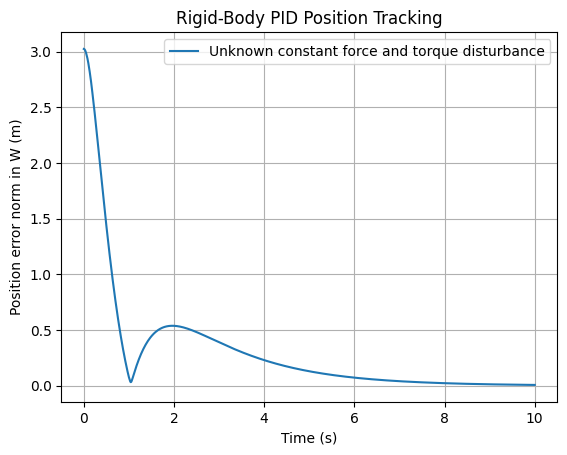

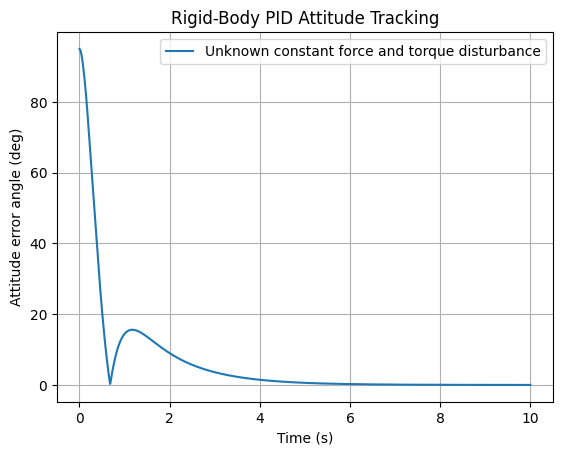

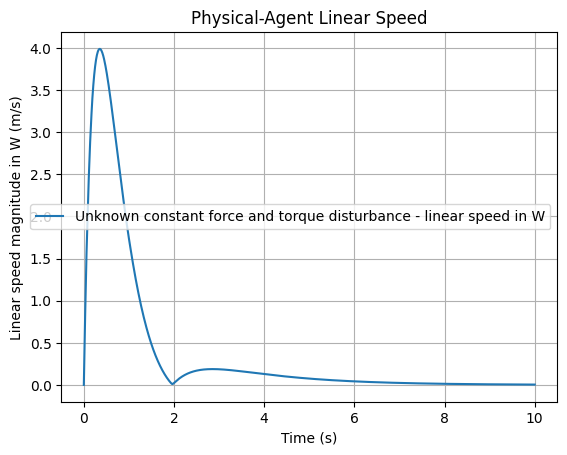

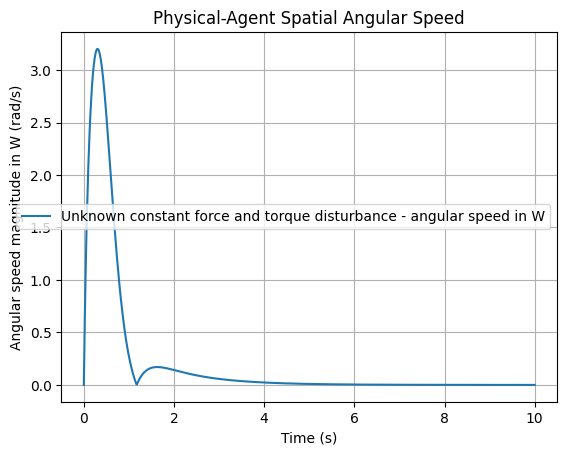

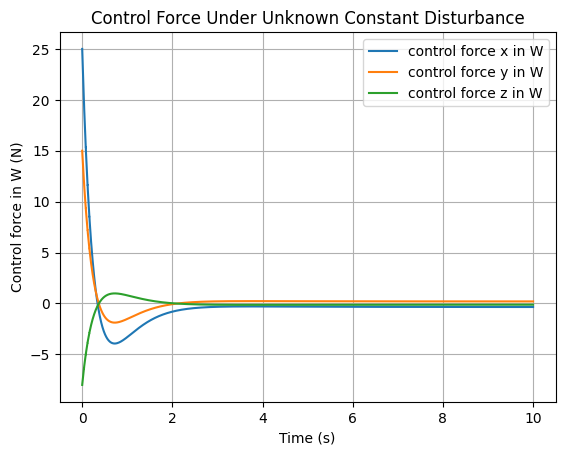

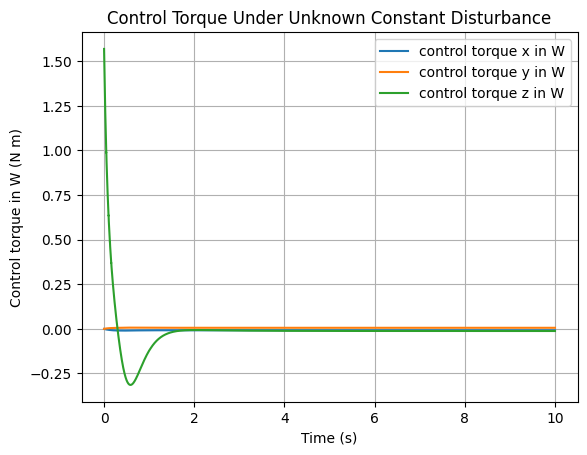


ARCHITECTURE CHECKS
Physical agents inserted into each Drake simulator: 1
Virtual agents inserted into each Drake simulator: 0
Virtual agent represented with existing Agent class: YES
Virtual state sent using CommunicationMessage: YES
Virtual synchronization implemented: NO
Physical-agent neighbor communication used: NO
Controller timestep equals physics timestep: YES
Actual disturbance directly supplied to controller: NO


In [ ]:
'''
baseline_result = run_test_case(
    baseline_case
)
'''
disturbance_result = run_test_case(
    constant_disturbance_case
)


all_results = [
    disturbance_result
]

plot_case_comparison(
    all_results
)

print("\n" + "=" * 72)
print("ARCHITECTURE CHECKS")
print("=" * 72)
print(
    "Physical agents inserted into each Drake simulator: 1"
)
print(
    "Virtual agents inserted into each Drake simulator: 0"
)
print(
    "Virtual agent represented with existing Agent class: YES"
)
print(
    "Virtual state sent using CommunicationMessage: YES"
)
print(
    "Virtual synchronization implemented: NO"
)
print(
    "Physical-agent neighbor communication used: NO"
)
print(
    "Controller timestep equals physics timestep: YES"
)
print(
    "Actual disturbance directly supplied to controller: NO"
)

In [ ]:
# ============================================================
# THREE-PHYSICAL-AGENT / THREE-VIRTUAL-AGENT PID TEST
#
# Each physical rigid body i tracks its own stationary virtual frame V_i
# with a constant pose offset expressed in that virtual frame.
#
# IMPORTANT
# ---------
# Run this script AFTER executing all simulation-platform definition
# cells in Realistic_Test.ipynb.
#
# This test uses the existing platform classes without modifying them:
#
#   Controller, ZeroController, Agent, AgentState, BodyConfig,
#   CommunicationMessage, CommunicationGraph, EnvironmentConfig,
#   ConstantExternalWrench, MultiAgentSimulator, rotation_matrix_z
#
# No virtual synchronization is implemented in this test.
# ============================================================

import builtins
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# FRAME NOTATION
# ============================================================
#
# W   : inertial/world frame
# B_i : current body-fixed frame of physical Agent i
# V_i : local virtual frame associated with physical Agent i
# r_i : desired/reference body frame for physical Agent i
#
# R_WBi : maps vector coordinates from B_i to W
# R_WVi : maps vector coordinates from V_i to W
# R_Viri: maps vector coordinates from r_i to V_i
# R_Wri : maps vector coordinates from r_i to W
#
# d_i_Vi:
#   constant vector from the origin of V_i to the origin of r_i,
#   expressed using the axes of V_i.
#
# The constant virtual-frame offset is applied as:
#
#   g_Wri = g_WVi * g_Viri
#
# Therefore:
#
#   o_ri_W = o_vi_W + R_WVi @ d_i_Vi
#   R_Wri  = R_WVi @ R_Viri
#
# A variable ending in _W is represented in world coordinates W.
# A variable ending in _B is represented in physical-body coordinates B.
# A variable ending in _V is represented in virtual-frame coordinates V.
# ============================================================


# ============================================================
# MATHEMATICAL HELPERS
# ============================================================

def source_vee(skew_matrix):
    """Convert a 3x3 skew-symmetric matrix to its associated vector."""
    S = np.asarray(skew_matrix, dtype=float).reshape(3, 3)
    return np.array([S[2, 1], S[0, 2], S[1, 0]], dtype=float)


def copy_agent_state(state):
    """Create an independent AgentState snapshot."""
    return AgentState(
        position=np.asarray(state.position, dtype=float).copy(),
        orientation=np.asarray(state.orientation, dtype=float).copy(),
        linear_velocity=np.asarray(
            state.linear_velocity,
            dtype=float,
        ).copy(),
        angular_velocity=np.asarray(
            state.angular_velocity,
            dtype=float,
        ).copy(),
    )


def validate_rotation_matrix(R, name):
    """Validate that R is a proper SO(3) rotation matrix."""
    R = np.asarray(R, dtype=float)

    if R.shape != (3, 3):
        raise ValueError(f"{name} must have shape (3, 3).")

    if not np.allclose(R.T @ R, np.eye(3), atol=1e-7):
        raise ValueError(f"{name} must satisfy R.T @ R = I.")

    if not np.isclose(np.linalg.det(R), 1.0, atol=1e-7):
        raise ValueError(f"{name} must have determinant +1.")


def rotation_error_angle_deg(R_Wr, R_WB):
    """
    Return the geodesic angle between desired orientation R_Wr and
    actual orientation R_WB, in degrees.
    """
    R_relative = np.asarray(R_Wr).T @ np.asarray(R_WB)
    cosine = (np.trace(R_relative) - 1.0) / 2.0
    cosine = np.clip(cosine, -1.0, 1.0)
    return float(np.degrees(np.arccos(cosine)))


# ============================================================
# STATIONARY VIRTUAL-AGENT RUNTIME
# ============================================================

class StationaryVirtualAgentRuntime:
    """
    Experiment-level runtime for one stationary virtual agent.

    The virtual agent uses the existing Agent class, but it is NOT
    inserted into MultiAgentSimulator. Therefore, it has no Drake body.

    Current state quantities:
      position              : virtual origin position expressed in W
      orientation           : R_WV, mapping V coordinates to W
      linear_velocity       : virtual-origin linear velocity in W = 0
      angular_velocity      : virtual spatial angular velocity in W = 0
      linear_acceleration_W : virtual-origin linear acceleration in W = 0
      angular_acceleration_W: virtual spatial angular acceleration in W = 0

    Later, its ZeroController can be replaced by a virtual synchronization
    controller without changing the physical rigid-body PID controller.
    """

    def __init__(self, virtual_agent):
        self.virtual_agent = virtual_agent
        cfg = virtual_agent.config

        self.initial_state = AgentState(
            position=cfg.initial_position,
            orientation=cfg.initial_orientation,
            linear_velocity=cfg.initial_linear_velocity,
            angular_velocity=cfg.initial_angular_velocity,
        )

        if np.linalg.norm(self.initial_state.linear_velocity) > 1e-12:
            raise ValueError(
                f"Virtual Agent {virtual_agent.id} must have zero "
                "linear velocity expressed in W for this stationary test."
            )

        if np.linalg.norm(self.initial_state.angular_velocity) > 1e-12:
            raise ValueError(
                f"Virtual Agent {virtual_agent.id} must have zero "
                "spatial angular velocity expressed in W for this test."
            )

        self.reset()

    def reset(self):
        self.state = copy_agent_state(self.initial_state)
        self.linear_acceleration_W = np.zeros(3)
        self.angular_acceleration_W = np.zeros(3)
        self.update_count = 0
        self.update_times = []
        self.virtual_agent.controller.reset()

    def update(self, t, dt, neighbor_virtual_states=None):
        """
        Update this local virtual agent.

        No virtual synchronization is active, so neighbor_virtual_states
        is an empty dictionary and the virtual state remains stationary.
        """
        if neighbor_virtual_states is None:
            neighbor_virtual_states = {}

        self.virtual_agent.controller.update(
            t=t,
            dt=dt,
            self_state=self.state,
            neighbor_states=neighbor_virtual_states,
        )

        self.linear_acceleration_W = np.zeros(3)
        self.angular_acceleration_W = np.zeros(3)

        if dt > 0.0:
            self.update_count += 1
            self.update_times.append(float(t))


@dataclass
class LocalVirtualAgentPacket:
    """
    Local zero-delay packet from Virtual Agent i to Physical Agent i.

    state_message.state.position:
        virtual-frame origin position expressed in W

    state_message.state.orientation:
        R_WVi, mapping V_i coordinates into W

    state_message.state.linear_velocity:
        virtual-origin linear velocity expressed in W

    state_message.state.angular_velocity:
        virtual spatial angular velocity expressed in W

    linear_acceleration_W:
        virtual-origin linear acceleration expressed in W

    angular_acceleration_W:
        virtual spatial angular acceleration expressed in W
    """

    state_message: object
    linear_acceleration_W: np.ndarray
    angular_acceleration_W: np.ndarray


class LocalVirtualAgentChannel:
    """
    Zero-delay local connection from one virtual agent to its associated
    physical rigid-body controller.

    This is not neighbor-to-neighbor virtual synchronization. It is a
    local data path inside one decentralized node.
    """

    def __init__(self, virtual_runtime, physical_receiver_id):
        self.virtual_runtime = virtual_runtime
        self.physical_receiver_id = physical_receiver_id
        self.reset()

    def reset(self):
        self.virtual_runtime.reset()
        self.message_count = 0
        self.message_times = []
        self.latest_packet = None

    def receive(self, t, dt):
        self.virtual_runtime.update(
            t=t,
            dt=dt,
            neighbor_virtual_states={},
        )

        message = CommunicationMessage(
            sender_id=self.virtual_runtime.virtual_agent.id,
            receiver_id=self.physical_receiver_id,
            send_time=float(t),
            delivery_time=float(t),
            state=copy_agent_state(self.virtual_runtime.state),
        )

        packet = LocalVirtualAgentPacket(
            state_message=message,
            linear_acceleration_W=np.asarray(
                self.virtual_runtime.linear_acceleration_W,
                dtype=float,
            ).copy(),
            angular_acceleration_W=np.asarray(
                self.virtual_runtime.angular_acceleration_W,
                dtype=float,
            ).copy(),
        )

        self.message_count += 1
        self.message_times.append(float(t))
        self.latest_packet = packet
        return packet


# ============================================================
# COMPLETE REFERENCE OBJECT
# ============================================================

@dataclass
class RigidBodyReference:
    """
    Complete tracking reference required by the rigid-body PID law.

    o_r_W      : desired physical center-of-mass position in W
    R_Wr       : desired orientation, mapping r coordinates to W
    v_r_W      : desired physical linear velocity expressed in W
    a_r_W      : desired physical linear acceleration expressed in W
    omega_r_W  : desired spatial angular velocity expressed in W
    alpha_r_W  : desired spatial angular acceleration expressed in W
    p_r_W      : desired linear momentum expressed in W
    pi_r_W     : desired spatial angular momentum expressed in W
    pi_dot_r_W : desired spatial angular-momentum derivative in W
    """

    o_r_W: np.ndarray
    R_Wr: np.ndarray
    v_r_W: np.ndarray
    a_r_W: np.ndarray
    omega_r_W: np.ndarray
    alpha_r_W: np.ndarray
    p_r_W: np.ndarray
    pi_r_W: np.ndarray
    pi_dot_r_W: np.ndarray


# ============================================================
# CONSTANT OFFSET EXPRESSED IN THE LOCAL VIRTUAL FRAME
# ============================================================

class ConstantVirtualFrameOffsetReferenceGenerator:
    """
    Generate Physical Agent i's desired rigid-body reference from its
    own Virtual Agent i using a constant offset expressed in V_i.

    Pose composition:

        g_Wri = g_WVi * g_Viri

    Translation:

        d_i_Vi  = constant displacement from V_i origin to r_i origin,
                  expressed using V_i axes

        d_i_W   = R_WVi @ d_i_Vi

        o_ri_W  = o_vi_W + d_i_W

    Orientation:

        R_Viri  = constant orientation of desired frame r_i relative
                  to virtual frame V_i

        R_Wri   = R_WVi @ R_Viri

    This is especially suitable for later virtual synchronization:
    when V_i translates or rotates, the desired physical pose moves
    with V_i while the local offset remains constant in V_i.
    """

    def __init__(
        self,
        offset_position_V,
        offset_orientation_Vr,
        mass,
        inertia_B,
    ):
        self.d_V = np.asarray(
            offset_position_V,
            dtype=float,
        ).reshape(3)

        self.R_Vr = np.asarray(
            offset_orientation_Vr,
            dtype=float,
        ).reshape(3, 3)

        validate_rotation_matrix(
            self.R_Vr,
            "offset_orientation_Vr",
        )

        self.mass = float(mass)
        self.inertia_B = np.asarray(
            inertia_B,
            dtype=float,
        ).reshape(3, 3)

    def generate(self, virtual_packet):
        virtual_state = virtual_packet.state_message.state

        # --------------------------------------------------------
        # Virtual-agent quantities represented in W
        # --------------------------------------------------------
        o_v_W = np.asarray(virtual_state.position, dtype=float)
        R_WV = np.asarray(virtual_state.orientation, dtype=float)
        v_v_W = np.asarray(
            virtual_state.linear_velocity,
            dtype=float,
        )
        omega_v_W = np.asarray(
            virtual_state.angular_velocity,
            dtype=float,
        )
        a_v_W = np.asarray(
            virtual_packet.linear_acceleration_W,
            dtype=float,
        )
        alpha_v_W = np.asarray(
            virtual_packet.angular_acceleration_W,
            dtype=float,
        )

        # --------------------------------------------------------
        # Constant offset expressed in V
        # --------------------------------------------------------

        # Convert the constant offset vector from V coordinates to W.
        d_W = R_WV @ self.d_V

        # Desired position of the physical reference origin in W.
        o_r_W = o_v_W + d_W

        # Desired orientation, mapping reference coordinates r to W.
        R_Wr = R_WV @ self.R_Vr

        # --------------------------------------------------------
        # Reference kinematics represented in W
        # --------------------------------------------------------
        #
        # These expressions also remain valid when the virtual frame
        # later moves during virtual synchronization.

        # Desired reference-origin linear velocity in W.
        v_r_W = v_v_W + np.cross(omega_v_W, d_W)

        # Desired reference-origin linear acceleration in W.
        a_r_W = (
            a_v_W
            + np.cross(alpha_v_W, d_W)
            + np.cross(
                omega_v_W,
                np.cross(omega_v_W, d_W),
            )
        )

        # Because R_Vr is constant, r and V have the same spatial
        # angular velocity and acceleration, represented in W.
        omega_r_W = omega_v_W.copy()
        alpha_r_W = alpha_v_W.copy()

        # Desired linear momentum represented in W.
        p_r_W = self.mass * v_r_W

        # Desired inertia tensor represented in W.
        inertia_r_W = R_Wr @ self.inertia_B @ R_Wr.T

        # Desired spatial angular momentum represented in W.
        pi_r_W = inertia_r_W @ omega_r_W

        # Desired spatial angular-momentum derivative represented in W.
        pi_dot_r_W = (
            inertia_r_W @ alpha_r_W
            + np.cross(omega_r_W, pi_r_W)
        )

        return RigidBodyReference(
            o_r_W=o_r_W,
            R_Wr=R_Wr,
            v_r_W=v_r_W,
            a_r_W=a_r_W,
            omega_r_W=omega_r_W,
            alpha_r_W=alpha_r_W,
            p_r_W=p_r_W,
            pi_r_W=pi_r_W,
            pi_dot_r_W=pi_dot_r_W,
        )


# ============================================================
# SOURCE RIGID-BODY PID CONTROLLER
# ============================================================

class SourceRigidBodyPIDController(Controller):
    """
    Source-oriented rigid-body PID controller.

    Every returned control force and torque is expressed in W.

    TRANSLATION
    -----------
      e_o_W       = o_r_W - o_W
      p_W         = M v_W
      p_e_W       = p_r_W - p_W
      dot(e_Io_W) = e_o_W

      f_u_W = M a_r_W
              - f_e_for_controller_W
              + k_Po e_o_W
              + k_Dp p_e_W
              + k_Io e_Io_W

    ROTATION
    --------
      R_e       = R_Wr R_WB^T
      omega_e_W = omega_r_W - R_e omega_W
      pi_W      = I_W omega_W
      pi_e_W    = R_e^T pi_r_W - pi_W

      hat(e_R_W) = 0.5 (R_e K - K R_e^T)
      dot(e_IR_W) = e_R_W

      tau_ff_W = R_e^T(
                     pi_dot_r_W
                     - omega_e_W x pi_r_W
                 )

      tau_u_W = tau_ff_W
                - tau_e_for_controller_W
                + k_PR e_R_W
                + k_DR pi_e_W
                + k_IR e_IR_W

    The actual ExternalForceModel disturbance is not supplied to this
    controller. Both controller-side external-wrench inputs are zero.
    """

    def __init__(
        self,
        agent_id,
        local_virtual_channel,
        reference_generator,
        mass,
        inertia_B,
        k_Po,
        k_Dp,
        k_Io,
        k_PR,
        k_DR,
        k_IR,
        attitude_potential_K,
        external_force_for_controller_W=None,
        external_torque_for_controller_W=None,
    ):
        self.agent_id = agent_id
        self.local_virtual_channel = local_virtual_channel
        self.reference_generator = reference_generator

        self.mass = float(mass)
        self.inertia_B = np.asarray(
            inertia_B,
            dtype=float,
        ).reshape(3, 3)

        self.k_Po = float(k_Po)
        self.k_Dp = float(k_Dp)
        self.k_Io = float(k_Io)
        self.k_PR = float(k_PR)
        self.k_DR = float(k_DR)
        self.k_IR = float(k_IR)

        self.K = np.asarray(
            attitude_potential_K,
            dtype=float,
        ).reshape(3, 3)

        if not np.allclose(self.K, self.K.T, atol=1e-12):
            raise ValueError("attitude_potential_K must be symmetric.")

        self.f_e_for_controller_W = (
            np.zeros(3)
            if external_force_for_controller_W is None
            else np.asarray(
                external_force_for_controller_W,
                dtype=float,
            ).reshape(3)
        )

        self.tau_e_for_controller_W = (
            np.zeros(3)
            if external_torque_for_controller_W is None
            else np.asarray(
                external_torque_for_controller_W,
                dtype=float,
            ).reshape(3)
        )

        self.reset()

    def reset(self):
        # Integral of position error, represented in W.
        self.e_Io_W = np.zeros(3)

        # Integral of geometric attitude error, represented in W.
        self.e_IR_W = np.zeros(3)

        self.latest_virtual_packet = None
        self.latest_reference = None
        self.update_count = 0
        self.history = []
        self.physical_neighbor_count_history = []
        self.local_virtual_channel.reset()

    def _calculate_errors(self, self_state, reference):
        # Current physical center-of-mass position represented in W.
        o_W = np.asarray(self_state.position, dtype=float)

        # Current physical orientation R_WB maps B coordinates to W.
        R_WB = np.asarray(self_state.orientation, dtype=float)

        # Current physical linear velocity represented in W.
        v_W = np.asarray(self_state.linear_velocity, dtype=float)

        # Current physical spatial angular velocity represented in W.
        omega_W = np.asarray(
            self_state.angular_velocity,
            dtype=float,
        )

        # Translational errors represented in W.
        e_o_W = reference.o_r_W - o_W
        p_W = self.mass * v_W
        p_e_W = reference.p_r_W - p_W

        # Right-invariant rotation error.
        R_e = reference.R_Wr @ R_WB.T

        # Spatial angular-velocity error represented in W.
        omega_e_W = reference.omega_r_W - R_e @ omega_W

        # Physical inertia tensor represented in W.
        inertia_W = R_WB @ self.inertia_B @ R_WB.T

        # Physical spatial angular momentum represented in W.
        pi_W = inertia_W @ omega_W

        # Angular-momentum error represented in W.
        pi_e_W = R_e.T @ reference.pi_r_W - pi_W

        # Geometric attitude error represented in W.
        e_R_hat = 0.5 * (
            R_e @ self.K
            - self.K @ R_e.T
        )
        e_R_W = source_vee(e_R_hat)

        return {
            "o_W": o_W,
            "R_WB": R_WB,
            "v_W": v_W,
            "omega_W": omega_W,
            "e_o_W": e_o_W,
            "p_W": p_W,
            "p_e_W": p_e_W,
            "R_e": R_e,
            "omega_e_W": omega_e_W,
            "inertia_W": inertia_W,
            "pi_W": pi_W,
            "pi_e_W": pi_e_W,
            "e_R_W": e_R_W,
        }

    def update(self, t, dt, self_state, neighbor_states):
        # Receive this physical agent's own local virtual state.
        self.latest_virtual_packet = self.local_virtual_channel.receive(
            t=t,
            dt=dt,
        )

        # Generate the complete rigid-body reference.
        self.latest_reference = self.reference_generator.generate(
            self.latest_virtual_packet,
        )

        errors = self._calculate_errors(
            self_state,
            self.latest_reference,
        )

        if dt > 0.0:
            self.e_Io_W += errors["e_o_W"] * dt
            self.e_IR_W += errors["e_R_W"] * dt
            self.update_count += 1

        # No physical-neighbor state is used in this test.
        self.physical_neighbor_count_history.append(
            len(neighbor_states),
        )

    def compute_control(self, t, self_state, neighbor_states):
        if self.latest_reference is None:
            raise RuntimeError(
                "No local virtual-agent reference is available. "
                "update() must run before compute_control()."
            )

        reference = self.latest_reference
        errors = self._calculate_errors(self_state, reference)

        # --------------------------------------------------------
        # TRANSLATIONAL CONTROL FORCE, REPRESENTED IN W
        # --------------------------------------------------------
        force_feedforward_W = self.mass * reference.a_r_W
        force_proportional_W = self.k_Po * errors["e_o_W"]
        force_derivative_W = self.k_Dp * errors["p_e_W"]
        force_integral_W = self.k_Io * self.e_Io_W

        force_control_W = (
            force_feedforward_W
            - self.f_e_for_controller_W
            + force_proportional_W
            + force_derivative_W
            + force_integral_W
        )

        # --------------------------------------------------------
        # ROTATIONAL CONTROL TORQUE, REPRESENTED IN W
        # --------------------------------------------------------
        torque_feedforward_W = (
            errors["R_e"].T
            @ (
                reference.pi_dot_r_W
                - np.cross(
                    errors["omega_e_W"],
                    reference.pi_r_W,
                )
            )
        )

        torque_proportional_W = self.k_PR * errors["e_R_W"]
        torque_derivative_W = self.k_DR * errors["pi_e_W"]
        torque_integral_W = self.k_IR * self.e_IR_W

        torque_control_W = (
            torque_feedforward_W
            - self.tau_e_for_controller_W
            + torque_proportional_W
            + torque_derivative_W
            + torque_integral_W
        )

        self.history.append({
            "time": float(t),
            "o_r_W": reference.o_r_W.copy(),
            "R_Wr": reference.R_Wr.copy(),
            "e_o_W": errors["e_o_W"].copy(),
            "p_e_W": errors["p_e_W"].copy(),
            "e_R_W": errors["e_R_W"].copy(),
            "pi_e_W": errors["pi_e_W"].copy(),
            "e_Io_W": self.e_Io_W.copy(),
            "e_IR_W": self.e_IR_W.copy(),
            "force_control_W": force_control_W.copy(),
            "torque_control_W": torque_control_W.copy(),
        })

        return force_control_W, torque_control_W


# ============================================================
# TEST CONFIGURATION
# ============================================================

PHYSICS_DT = 0.001
CONTROL_DT = PHYSICS_DT
LOG_DT = 0.01
SIMULATION_DURATION = 10.0
REALTIME_RATE = 1.0  # Set 0.0 for fastest possible execution.

PHYSICAL_AGENT_IDS = [0, 1, 2]
VIRTUAL_AGENT_IDS = ["virtual_0", "virtual_1", "virtual_2"]

MASS = 1.0
INERTIA_B = np.diag([0.08, 0.06, 0.05])

# Test-tuning gains; they were not numerically specified in the source.
K_PO = 10.0
K_DP = 6.0
K_IO = 4.0
K_PR = 1.5
K_DR = 10.0
K_IR = 1.0

ATTITUDE_POTENTIAL_K = np.diag([1.0, 1.1, 1.2])

# Controller-side external wrench inputs represented in W.
# They remain zero, so actual disturbances are not directly compensated.
EXTERNAL_FORCE_FOR_CONTROLLER_W = np.zeros(3)
EXTERNAL_TORQUE_FOR_CONTROLLER_W = np.zeros(3)

# ------------------------------------------------------------
# Each row describes one decentralized physical/virtual node.
# ------------------------------------------------------------
#
# offset_position_V:
#   displacement from virtual origin V_i to desired physical origin r_i,
#   expressed along the local V_i axes.
#
# offset_orientation_Vr:
#   desired physical orientation relative to V_i.
#   It maps r_i coordinates into V_i coordinates.
# ------------------------------------------------------------

NODE_CONFIGS = [
    {
        "physical_id": 0,
        "virtual_id": "virtual_0",
        "virtual_position_W": np.array([0.0, 0.0, 1.0]),
        "R_WV": rotation_matrix_z(np.radians(0.0)),
        "offset_position_V": np.array([1.0, 0.0, 0.0]),
        "offset_orientation_Vr": rotation_matrix_z(np.radians(20.0)),
        "initial_physical_position_W": np.array([-1.0, -0.8, 1.7]),
        "initial_R_WB": rotation_matrix_z(np.radians(-45.0)),
        "physical_color": (0.20, 0.60, 1.00, 1.0),
        "virtual_color": (1.00, 0.55, 0.10, 1.0),
        "disturbance_force_W": np.array([0.25, -0.10, 0.08]),
        "disturbance_torque_W": np.array([0.006, -0.004, 0.008]),
    },
    {
        "physical_id": 1,
        "virtual_id": "virtual_1",
        "virtual_position_W": np.array([3.0, 0.0, 1.0]),
        "R_WV": rotation_matrix_z(np.radians(45.0)),
        "offset_position_V": np.array([1.0, 0.0, 0.0]),
        "offset_orientation_Vr": rotation_matrix_z(np.radians(-25.0)),
        "initial_physical_position_W": np.array([4.4, -1.1, 1.6]),
        "initial_R_WB": rotation_matrix_z(np.radians(85.0)),
        "physical_color": (0.25, 0.85, 0.35, 1.0),
        "virtual_color": (0.90, 0.30, 0.80, 1.0),
        "disturbance_force_W": np.array([-0.18, 0.16, -0.06]),
        "disturbance_torque_W": np.array([-0.005, 0.006, -0.007]),
    },
    {
        "physical_id": 2,
        "virtual_id": "virtual_2",
        "virtual_position_W": np.array([0.0, 3.0, 1.0]),
        "R_WV": rotation_matrix_z(np.radians(-30.0)),
        "offset_position_V": np.array([0.5, 1.0, 0.0]),
        "offset_orientation_Vr": rotation_matrix_z(np.radians(35.0)),
        "initial_physical_position_W": np.array([-1.0, 4.3, 1.8]),
        "initial_R_WB": rotation_matrix_z(np.radians(-90.0)),
        "physical_color": (0.90, 0.35, 0.25, 1.0),
        "virtual_color": (0.20, 0.90, 0.90, 1.0),
        "disturbance_force_W": np.array([0.12, 0.20, 0.05]),
        "disturbance_torque_W": np.array([0.004, 0.005, 0.009]),
    },
]

APPLY_CONSTANT_DISTURBANCES = True
DISTURBANCE_APPLICATION_POINT_B = np.zeros(3)


# ============================================================
# BUILD THREE-AGENT TEST
# ============================================================

def build_three_agent_test():
    physical_agents = []
    virtual_agents = {}
    virtual_runtimes = {}
    local_channels = {}
    controllers = {}
    reference_generators = {}
    expected_positions_W = {}
    expected_orientations_Wr = {}

    for node in NODE_CONFIGS:
        physical_id = node["physical_id"]
        virtual_id = node["virtual_id"]

        R_WV = np.asarray(node["R_WV"], dtype=float)
        d_V = np.asarray(node["offset_position_V"], dtype=float)
        R_Vr = np.asarray(node["offset_orientation_Vr"], dtype=float)
        o_v_W = np.asarray(node["virtual_position_W"], dtype=float)

        validate_rotation_matrix(R_WV, f"Agent {physical_id} R_WV")
        validate_rotation_matrix(R_Vr, f"Agent {physical_id} R_Vr")

        # Expected stationary desired pose.
        expected_positions_W[physical_id] = o_v_W + R_WV @ d_V
        expected_orientations_Wr[physical_id] = R_WV @ R_Vr

        # --------------------------------------------------------
        # Virtual Agent i: uses existing Agent class, but is not
        # inserted into the Drake simulator.
        # --------------------------------------------------------
        virtual_config = BodyConfig(
            mass=MASS,
            inertia_matrix=INERTIA_B,
            initial_position=o_v_W,
            initial_orientation=R_WV,
            initial_linear_velocity=np.zeros(3),   # represented in W
            initial_angular_velocity=np.zeros(3),  # represented in W
            size=(0.12, 0.12, 0.12),
            color=node["virtual_color"],
        )

        virtual_agent = Agent(
            agent_id=virtual_id,
            config=virtual_config,
            controller=ZeroController(),
            external_force_models=[],
            control_dt=CONTROL_DT,
            communication_dt=CONTROL_DT,
            communication_offset=0.0,
        )

        virtual_runtime = StationaryVirtualAgentRuntime(
            virtual_agent=virtual_agent,
        )

        local_channel = LocalVirtualAgentChannel(
            virtual_runtime=virtual_runtime,
            physical_receiver_id=physical_id,
        )

        reference_generator = ConstantVirtualFrameOffsetReferenceGenerator(
            offset_position_V=d_V,
            offset_orientation_Vr=R_Vr,
            mass=MASS,
            inertia_B=INERTIA_B,
        )

        controller = SourceRigidBodyPIDController(
            agent_id=physical_id,
            local_virtual_channel=local_channel,
            reference_generator=reference_generator,
            mass=MASS,
            inertia_B=INERTIA_B,
            k_Po=K_PO,
            k_Dp=K_DP,
            k_Io=K_IO,
            k_PR=K_PR,
            k_DR=K_DR,
            k_IR=K_IR,
            attitude_potential_K=ATTITUDE_POTENTIAL_K,
            external_force_for_controller_W=(
                EXTERNAL_FORCE_FOR_CONTROLLER_W
            ),
            external_torque_for_controller_W=(
                EXTERNAL_TORQUE_FOR_CONTROLLER_W
            ),
        )

        if APPLY_CONSTANT_DISTURBANCES:
            external_force_models = [
                ConstantExternalWrench(
                    force_W=np.asarray(
                        node["disturbance_force_W"],
                        dtype=float,
                    ),
                    torque_W=np.asarray(
                        node["disturbance_torque_W"],
                        dtype=float,
                    ),
                    point_B=DISTURBANCE_APPLICATION_POINT_B,
                )
            ]
        else:
            external_force_models = []

        physical_config = BodyConfig(
            mass=MASS,
            inertia_matrix=INERTIA_B,
            initial_position=node["initial_physical_position_W"],
            initial_orientation=node["initial_R_WB"],
            initial_linear_velocity=np.zeros(3),   # represented in W
            initial_angular_velocity=np.zeros(3),  # represented in W
            size=(0.25, 0.20, 0.15),
            color=node["physical_color"],
        )

        physical_agent = Agent(
            agent_id=physical_id,
            config=physical_config,
            controller=controller,
            external_force_models=external_force_models,
            control_dt=CONTROL_DT,
            communication_dt=CONTROL_DT,
            communication_offset=0.0,
        )

        physical_agents.append(physical_agent)
        virtual_agents[physical_id] = virtual_agent
        virtual_runtimes[physical_id] = virtual_runtime
        local_channels[physical_id] = local_channel
        controllers[physical_id] = controller
        reference_generators[physical_id] = reference_generator

    # Empty physical communication graph:
    # physical PID controllers receive no physical-neighbor states.
    simulator = MultiAgentSimulator(
        agents=physical_agents,
        time_step=PHYSICS_DT,
        environment=EnvironmentConfig(gravity=np.zeros(3)),
        communication_graph=CommunicationGraph.empty(
            PHYSICAL_AGENT_IDS,
        ),
        enable_agent_collisions=False,
    )

    return {
        "simulator": simulator,
        "physical_agents": physical_agents,
        "virtual_agents": virtual_agents,
        "virtual_runtimes": virtual_runtimes,
        "local_channels": local_channels,
        "controllers": controllers,
        "reference_generators": reference_generators,
        "expected_positions_W": expected_positions_W,
        "expected_orientations_Wr": expected_orientations_Wr,
    }


# ============================================================
# OPTIONAL STATIC MESHCAT REFERENCE VISUALIZATION
# ============================================================

def _draw_line_segment(meshcat, path, start_W, end_W, rgba, width=4.0):
    """Draw one world-coordinate line segment in Meshcat."""
    start_W = np.asarray(start_W, dtype=float).reshape(3, 1)
    end_W = np.asarray(end_W, dtype=float).reshape(3, 1)

    meshcat.SetLineSegments(
        path,
        start_W,
        end_W,
        line_width=width,
        rgba=rgba,
    )


def draw_frame_triad(meshcat, path, origin_W, R_WF, length=0.35):
    """
    Draw frame F at origin_W. R_WF maps F coordinates to W.
    X, Y, Z axes are drawn as red, green, and blue lines.
    """
    origin_W = np.asarray(origin_W, dtype=float)
    R_WF = np.asarray(R_WF, dtype=float)

    axis_data = [
        ("x", R_WF[:, 0], Rgba(1.0, 0.0, 0.0, 1.0)),
        ("y", R_WF[:, 1], Rgba(0.0, 1.0, 0.0, 1.0)),
        ("z", R_WF[:, 2], Rgba(0.0, 0.0, 1.0, 1.0)),
    ]

    for axis_name, axis_W, color in axis_data:
        _draw_line_segment(
            meshcat=meshcat,
            path=f"{path}/{axis_name}",
            start_W=origin_W,
            end_W=origin_W + length * axis_W,
            rgba=color,
            width=4.0,
        )


def draw_static_virtual_and_reference_frames(test):
    """
    Draw all stationary virtual frames and desired reference frames.

    This changes only Meshcat visualization; it does not change the
    simulation platform or physical dynamics.
    """
    meshcat = test["simulator"].meshcat

    try:
        for node in NODE_CONFIGS:
            agent_id = node["physical_id"]
            o_v_W = np.asarray(node["virtual_position_W"], dtype=float)
            R_WV = np.asarray(node["R_WV"], dtype=float)
            o_r_W = test["expected_positions_W"][agent_id]
            R_Wr = test["expected_orientations_Wr"][agent_id]

            draw_frame_triad(
                meshcat,
                path=f"virtual_references/agent_{agent_id}/virtual_frame",
                origin_W=o_v_W,
                R_WF=R_WV,
                length=0.40,
            )

            draw_frame_triad(
                meshcat,
                path=f"virtual_references/agent_{agent_id}/desired_frame",
                origin_W=o_r_W,
                R_WF=R_Wr,
                length=0.28,
            )

            _draw_line_segment(
                meshcat=meshcat,
                path=f"virtual_references/agent_{agent_id}/offset_line",
                start_W=o_v_W,
                end_W=o_r_W,
                rgba=Rgba(0.2, 0.2, 0.2, 1.0),
                width=3.0,
            )

    except Exception as error:
        print(
            "Static virtual/reference frame drawing was skipped because "
            f"this Drake version reported: {error}"
        )
        print(
            "The three physical rigid bodies will still be visible and "
            "the simulation can continue normally."
        )




In [ ]:
# ============================================================
# RUN AND POST-PROCESS
# ============================================================

def run_three_agent_test(test):
    simulator = test["simulator"]

    print("\n" + "=" * 78)
    print("THREE-AGENT LOCAL VIRTUAL-FRAME TRACKING TEST")
    print("=" * 78)
    print("Physics timestep (s):", PHYSICS_DT)
    print("Controller timestep (s):", CONTROL_DT)
    print("Virtual synchronization active: NO")
    print("Physical-neighbor communication active: NO")
    print("Constant offsets expressed in: each local virtual frame V_i")
    print("Constant disturbances active:", APPLY_CONSTANT_DISTURBANCES)
    print("Meshcat real-time rate:", REALTIME_RATE)

    print("\nEXPECTED STATIONARY REFERENCES")
    print("--------------------------------")

    for node in NODE_CONFIGS:
        agent_id = node["physical_id"]
        R_WV = np.asarray(node["R_WV"], dtype=float)
        d_V = np.asarray(node["offset_position_V"], dtype=float)
        d_W = R_WV @ d_V

        print(f"\nAgent {agent_id}")
        print("  Virtual origin o_v represented in W (m):")
        print(" ", node["virtual_position_W"])
        print("  Constant offset d represented in V_i (m):")
        print(" ", d_V)
        print("  Same offset converted to W, R_WV @ d_V (m):")
        print(" ", d_W)
        print("  Desired physical position o_r represented in W (m):")
        print(" ", test["expected_positions_W"][agent_id])

    draw_static_virtual_and_reference_frames(test)

    print("\nMeshcat URL:")
    print(simulator.meshcat.web_url())
    print(
        "Open the URL above. The three colored boxes are physical agents; "
        "the static triads show virtual and desired reference frames."
    )

    logger = simulator.simulate_with_logging(
        duration=SIMULATION_DURATION,
        realtime_rate=REALTIME_RATE,
        log_dt=LOG_DT,
    )

    data = logger.as_arrays()
    time = data["time"]

    results = {
        "logger": logger,
        "time": time,
        "position_error_norm": {},
        "attitude_error_deg": {},
        "positions_W": {},
        "orientations_WB": {},
        "linear_speed_W": {},
        "angular_speed_W": {},
    }

    print("\nFINAL RESULTS")
    print("-------------")

    for agent_id in PHYSICAL_AGENT_IDS:
        positions_W = data["positions"][agent_id]
        orientations_WB = data["orientations"][agent_id]
        linear_velocities_W = data["linear_velocities"][agent_id]
        angular_velocities_W = data["angular_velocities"][agent_id]

        expected_position_W = test["expected_positions_W"][agent_id]
        expected_orientation_Wr = test[
            "expected_orientations_Wr"
        ][agent_id]

        position_error_norm = np.linalg.norm(
            expected_position_W.reshape(1, 3) - positions_W,
            axis=1,
        )

        attitude_error_deg = np.array([
            rotation_error_angle_deg(
                expected_orientation_Wr,
                R_WB,
            )
            for R_WB in orientations_WB
        ])

        linear_speed_W = np.linalg.norm(
            linear_velocities_W,
            axis=1,
        )
        angular_speed_W = np.linalg.norm(
            angular_velocities_W,
            axis=1,
        )

        results["positions_W"][agent_id] = positions_W
        results["orientations_WB"][agent_id] = orientations_WB
        results["position_error_norm"][agent_id] = position_error_norm
        results["attitude_error_deg"][agent_id] = attitude_error_deg
        results["linear_speed_W"][agent_id] = linear_speed_W
        results["angular_speed_W"][agent_id] = angular_speed_W

        controller = test["controllers"][agent_id]
        channel = test["local_channels"][agent_id]

        maximum_physical_neighbors = (
            builtins.max(controller.physical_neighbor_count_history)
            if controller.physical_neighbor_count_history
            else 0
        )

        print(f"\nAgent {agent_id}")
        print(
            "  Final position error norm represented in W (m):",
            position_error_norm[-1],
        )
        print(
            "  Final attitude error angle (deg):",
            attitude_error_deg[-1],
        )
        print(
            "  Final linear speed magnitude represented in W (m/s):",
            linear_speed_W[-1],
        )
        print(
            "  Final spatial angular-speed magnitude in W (rad/s):",
            angular_speed_W[-1],
        )
        print("  Local virtual-state messages:", channel.message_count)
        print(
            "  Maximum physical-neighbor states used:",
            maximum_physical_neighbors,
        )

    return results


# ============================================================
# PLOTS
# ============================================================

def plot_three_agent_results(test, results):
    time = results["time"]

    plt.figure()
    for agent_id in PHYSICAL_AGENT_IDS:
        plt.plot(
            time,
            results["position_error_norm"][agent_id],
            label=f"Agent {agent_id}",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Position error norm represented in W (m)")
    plt.title("Three-Agent Position Tracking")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    for agent_id in PHYSICAL_AGENT_IDS:
        plt.plot(
            time,
            results["attitude_error_deg"][agent_id],
            label=f"Agent {agent_id}",
        )
    plt.xlabel("Time (s)")
    plt.ylabel("Attitude error angle (deg)")
    plt.title("Three-Agent Attitude Tracking")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    for agent_id in PHYSICAL_AGENT_IDS:
        positions_W = results["positions_W"][agent_id]
        plt.plot(
            positions_W[:, 0],
            positions_W[:, 1],
            label=f"Physical Agent {agent_id} trajectory",
        )

        virtual_position_W = np.asarray(
            NODE_CONFIGS[agent_id]["virtual_position_W"],
            dtype=float,
        )
        desired_position_W = test["expected_positions_W"][agent_id]

        plt.scatter(
            virtual_position_W[0],
            virtual_position_W[1],
            marker="x",
            label=f"Virtual origin {agent_id}",
        )
        plt.scatter(
            desired_position_W[0],
            desired_position_W[1],
            marker="o",
            label=f"Desired position {agent_id}",
        )

    plt.xlabel("World X position (m)")
    plt.ylabel("World Y position (m)")
    plt.title("Top View: Physical Trajectories and Virtual-Frame Offsets")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# EXECUTE
# ============================================================

if not np.isclose(CONTROL_DT, PHYSICS_DT, atol=1e-15):
    raise RuntimeError(
        "This test requires CONTROL_DT to equal PHYSICS_DT."
    )

three_agent_test = build_three_agent_test()


INFO:drake:Meshcat listening for connections at http://localhost:7002
/tmp/ipykernel_900/4003807957.py:301: DrakeDeprecationWarning: The parameter order and V_PB parameter name for SetFreeBodySpatialVelocity() are deprecated and will be removed 2026-06-01. Use context, body, V_JpJc instead.
  self.plant.SetFreeBodySpatialVelocity(



THREE-AGENT LOCAL VIRTUAL-FRAME TRACKING TEST
Physics timestep (s): 0.001
Controller timestep (s): 0.001
Virtual synchronization active: NO
Physical-neighbor communication active: NO
Constant offsets expressed in: each local virtual frame V_i
Constant disturbances active: True
Meshcat real-time rate: 1.0

EXPECTED STATIONARY REFERENCES
--------------------------------

Agent 0
  Virtual origin o_v represented in W (m):
  [0. 0. 1.]
  Constant offset d represented in V_i (m):
  [1. 0. 0.]
  Same offset converted to W, R_WV @ d_V (m):
  [1. 0. 0.]
  Desired physical position o_r represented in W (m):
  [1. 0. 1.]

Agent 1
  Virtual origin o_v represented in W (m):
  [3. 0. 1.]
  Constant offset d represented in V_i (m):
  [1. 0. 0.]
  Same offset converted to W, R_WV @ d_V (m):
  [0.70710678 0.70710678 0.        ]
  Desired physical position o_r represented in W (m):
  [3.70710678 0.70710678 1.        ]

Agent 2
  Virtual origin o_v represented in W (m):
  [0. 3. 1.]
  Constant offset d

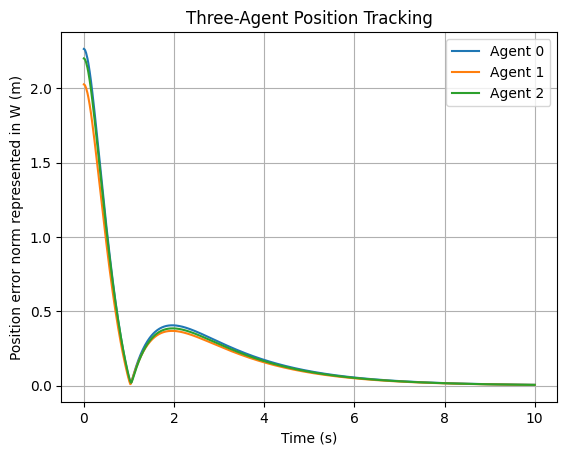

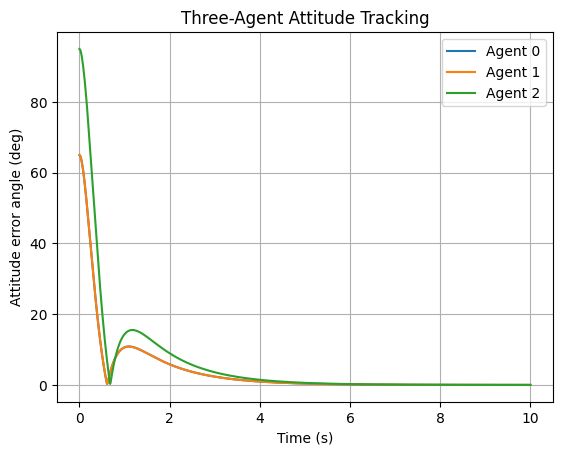

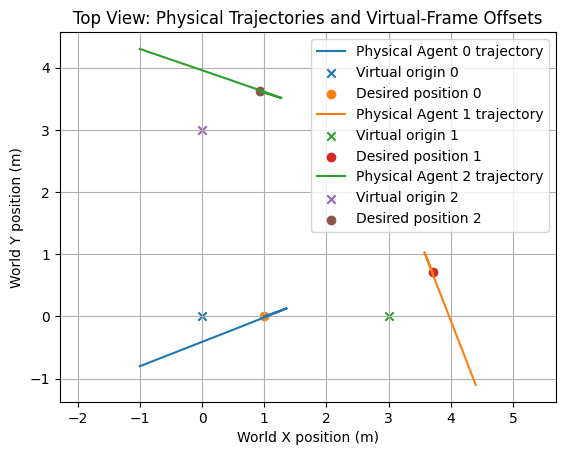


ARCHITECTURE CHECK
Physical agents inserted into Drake: 3
Virtual agents inserted into Drake: 0
Virtual agents represented with existing Agent class: 3
Local virtual-to-physical channels: 3
Virtual synchronization implemented: NO
Physical-neighbor controller states used: NO
Offsets expressed in each local virtual frame V_i: YES
Controller timestep equals physics timestep: YES
Actual disturbances directly supplied to PID controller: NO


In [ ]:
three_agent_results = run_three_agent_test(three_agent_test)
plot_three_agent_results(three_agent_test, three_agent_results)

print("\n" + "=" * 78)
print("ARCHITECTURE CHECK")
print("=" * 78)
print("Physical agents inserted into Drake: 3")
print("Virtual agents inserted into Drake: 0")
print("Virtual agents represented with existing Agent class: 3")
print("Local virtual-to-physical channels: 3")
print("Virtual synchronization implemented: NO")
print("Physical-neighbor controller states used: NO")
print("Offsets expressed in each local virtual frame V_i: YES")
print("Controller timestep equals physics timestep: YES")
print("Actual disturbances directly supplied to PID controller: NO")